# EDA

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import skew, kurtosis
from sklearn.cluster import KMeans
from scipy import stats
from sklearn.preprocessing import RobustScaler
import warnings
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage



warnings.simplefilter(action='ignore', category=FutureWarning)


In [2]:
data = pd.read_csv('sampleSuperstore.csv', encoding='cp1252')

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

The dataset contains no missing values.


In [5]:
data.select_dtypes(include = ['object']).nunique()

Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
dtype: int64

In [6]:
data.drop_duplicates().head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


There are no duplicate entries. The 'Country' field is unique for all records, while 'Customer Name' is redundant as it maps directly to 'Customer ID'. Additionally, 'Postal Code' corresponds directly to 'City' and provides no analytical value.

In [7]:
data = data.drop(['Country','Customer Name','Row ID','Postal Code'], axis = 1)

In [8]:
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

data['Month'] = data['Order Date'].dt.month
data['Year'] = data['Order Date'].dt.year
data['Days_to_Ship'] = (data['Ship Date'] - data['Order Date']).dt.days
data = data.drop(['Order Date','Ship Date'], axis=1)

In [9]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

data['Order_Season'] = data['Month'].apply(get_season)



In [10]:
object_columns = data.select_dtypes(include = ['object']).columns
for i in object_columns:
    if data[i].nunique() < 5:
        print(f'Column {i}:{data[i].unique()}')

Column Ship Mode:['Second Class' 'Standard Class' 'First Class' 'Same Day']
Column Segment:['Consumer' 'Corporate' 'Home Office']
Column Region:['South' 'West' 'Central' 'East']
Column Category:['Furniture' 'Office Supplies' 'Technology']
Column Order_Season:['Fall' 'Summer' 'Spring' 'Winter']


In [11]:
data.describe()

,Sales,Quantity,Discount,Profit,Month,Year,Days_to_Ship
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,7.809686,2015.722233,3.958175
std,623.245101,2.225110,0.206452,234.260108,3.284654,1.123555,1.747567
min,0.444000,1.000000,0.000000,-6599.978000,1.000000,2014.000000,0.000000
25%,17.280000,2.000000,0.000000,1.728750,5.000000,2015.000000,3.000000
50%,54.490000,3.000000,0.200000,8.666500,9.000000,2016.000000,4.000000
75%,209.940000,5.000000,0.200000,29.364000,11.000000,2017.000000,5.000000
max,22638.480000,14.000000,0.800000,8399.976000,12.000000,2017.000000,7.000000


The dataset spans from 2014 to 2017. Delivery times range from 0 to 7 days, with an average lead time of 3.95 days. Discounts range from 0% to 80%, averaging 15%. Both sales and profit figures exhibit a wide range of values, indicating high variability.

In [12]:
data.describe(include = 'object')

,Order ID,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,Product Name,Order_Season
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,3,531,49,4,1862,3,17,1850,4
top,CA-2017-100111,Standard Class,WB-21850,Consumer,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,Fall
freq,14,5968,37,5191,915,2001,3203,19,6026,1523,48,3673


The number of unique Customer IDs is lower than the total order count, indicating that customers have placed multiple orders within the dataset. Furthermore, the number of unique Order IDs is less than the total row count, which implies that a single order can consist of multiple products (line items).

# TRANSACTION SEGMENTATION

## EDA

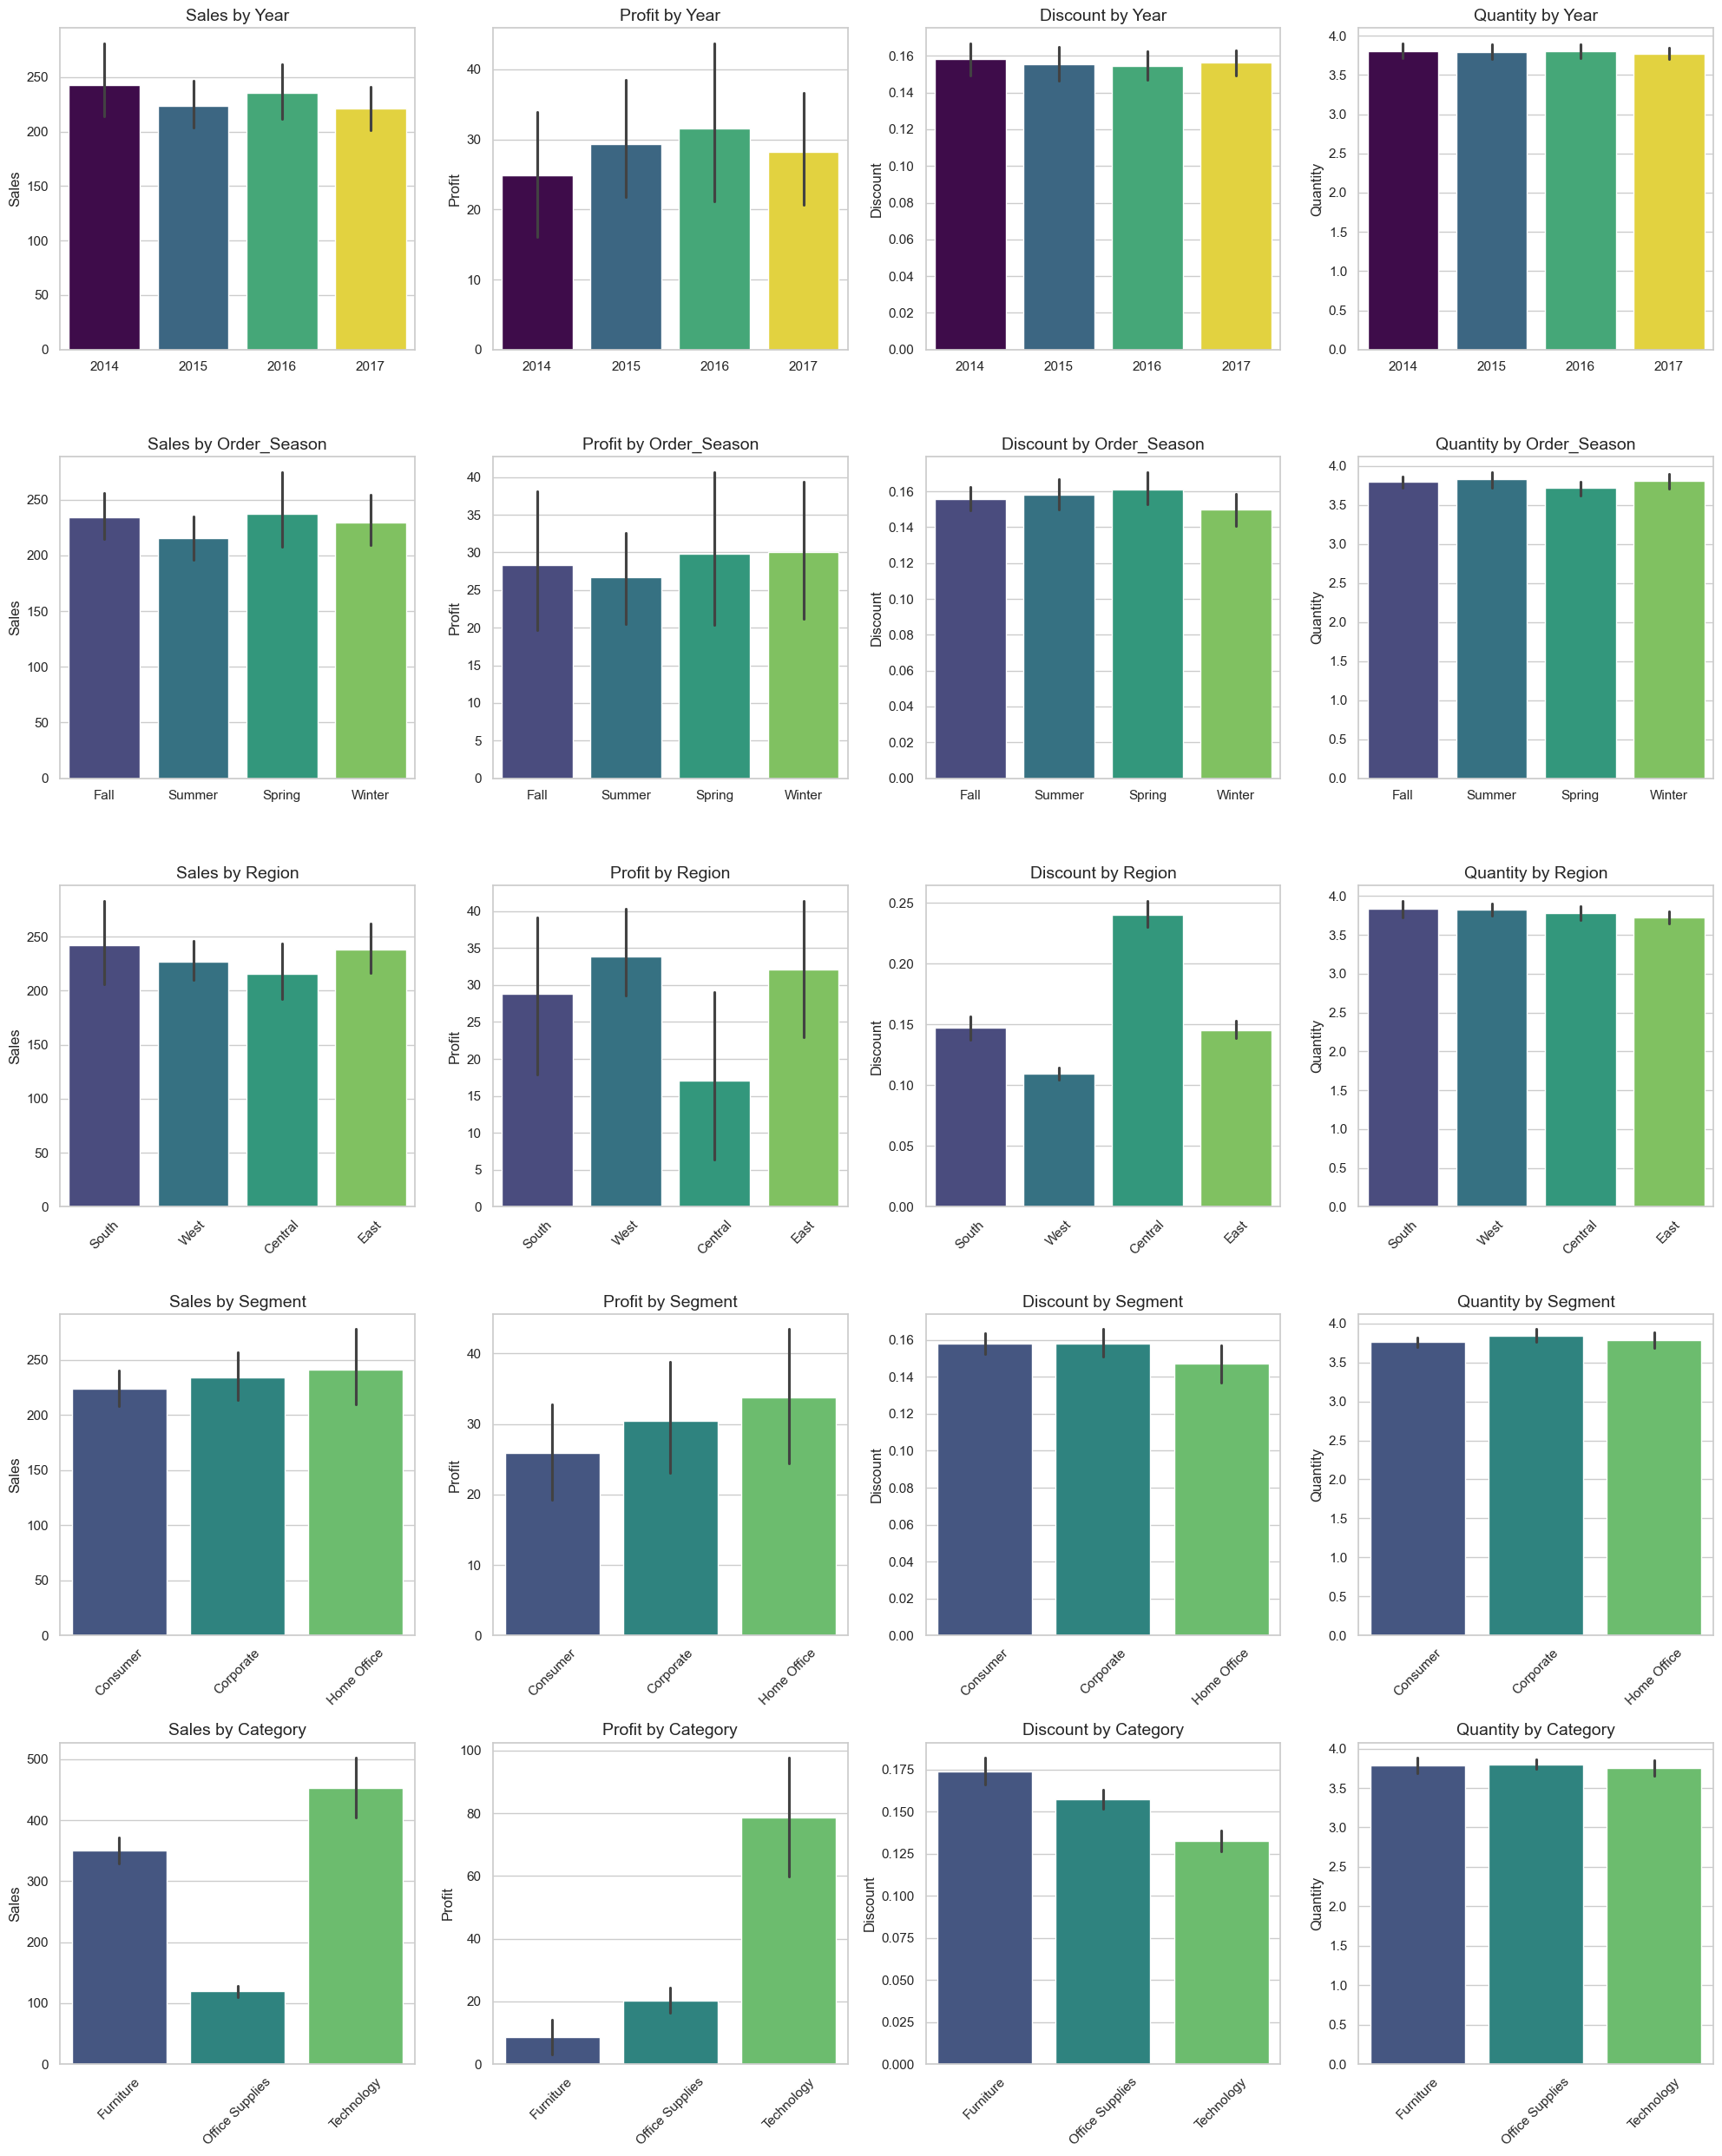

In [13]:
sns.set_theme(style="whitegrid")
metrics = ['Sales', 'Profit', 'Discount', 'Quantity']
dimensions = ['Year', 'Order_Season', 'Region', 'Segment', 'Category']

fig, axes = plt.subplots(nrows=len(dimensions), ncols=len(metrics), figsize=(20, 25))

for i, dim in enumerate(dimensions):
    for j, metric in enumerate(metrics):
        sns.barplot(ax=axes[i, j], x=dim, y=metric, data=data, palette='viridis', hue=dim, legend=False)
        
        axes[i, j].set_title(f'{metric} by {dim}', fontsize=14)
        axes[i, j].set_xlabel('')
        axes[i, j].set_ylabel(metric)
        
        if i >= 2: 
            axes[i, j].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

It is evident that the Central Region offers the highest average discounts, resulting in the lowest profit margins for the same sales volume. A similar trend is observed across Categories, where steeper discounts for 'Furniture' and 'Office Supplies' lead to significantly lower profitability.

Next, let's examine the Profit metrics

In [14]:
region_grouped = data.groupby('Region')[['Sales','Profit','Discount','Quantity']].mean()
region_grouped

,Sales,Profit,Discount,Quantity
Region,,,,
Central,215.772661,17.092709,0.240353,3.779595
East,238.336110,32.135808,0.145365,3.728230
South,241.803645,28.857673,0.147253,3.832716
West,226.493233,33.849032,0.109335,3.829535


Lable Encoding:

Central - 0 - High discount / Lowest profit

South - 1 - Moderate discount / Moderate profit

East -2 - Moderate discount / High profit

West - 3 - Low discount / High profit

In [15]:
category_grouped = data.groupby('Category')[['Sales','Profit','Discount','Quantity']].mean()
category_grouped

,Sales,Profit,Discount,Quantity
Category,,,,
Furniture,349.834887,8.699327,0.173923,3.785007
Office Supplies,119.324101,20.327050,0.157285,3.801195
Technology,452.709276,78.752002,0.132323,3.756903


Lable Encoding: <br>

Furniture - 0 - High discount / Low profit<br>
Office Supplies - 1 - Moderate discount / Moderate profit<br>
Technology - 2 - Low discount / High profit<br>

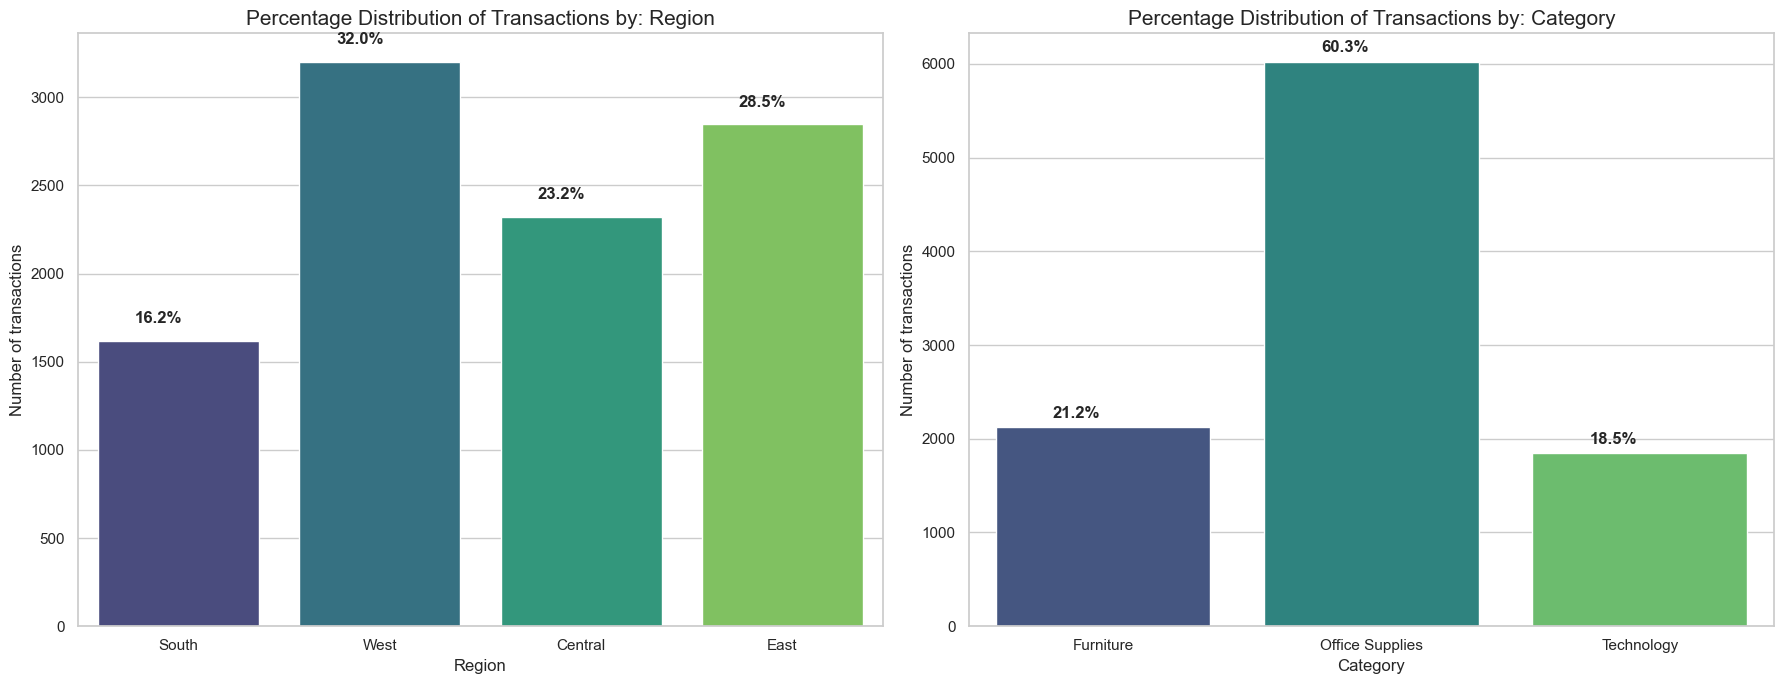

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
total = len(data)

attributes = ['Region', 'Category']

for i, attr in enumerate(attributes):
    ax = sns.countplot(x=attr, data=data, palette='viridis', ax=axes[i], hue=attr, legend=False)
    
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        x = p.get_x() + p.get_width() / 2 - 0.1  
        y = p.get_height() + (total * 0.01)     
        ax.annotate(percentage, (x, y), fontsize=12, fontweight='bold', ha='center')

    axes[i].set_title(f'Percentage Distribution of Transactions by: {attr}', fontsize=15)
    axes[i].set_ylabel('Number of transactions')
    axes[i].set_xlabel(attr)

plt.tight_layout()
plt.show()

It is evident that although Technology has the lowest transaction volume, it yields significantly higher average profits. Conversely, despite strong sales performance, Furniture generates the lowest profit margins due to having the highest average discounts. Office Supplies is the most frequently sold category; however, it produces the lowest Sales figures—likely due to lower unit prices—while maintaining healthier profit margins than Furniture. <br>
Regarding Regions, although the West is the most prominent in terms of volume, it maintains the lowest average discount. This indicates that peak profitability is not solely a function of market presence, but also of effective discount management.

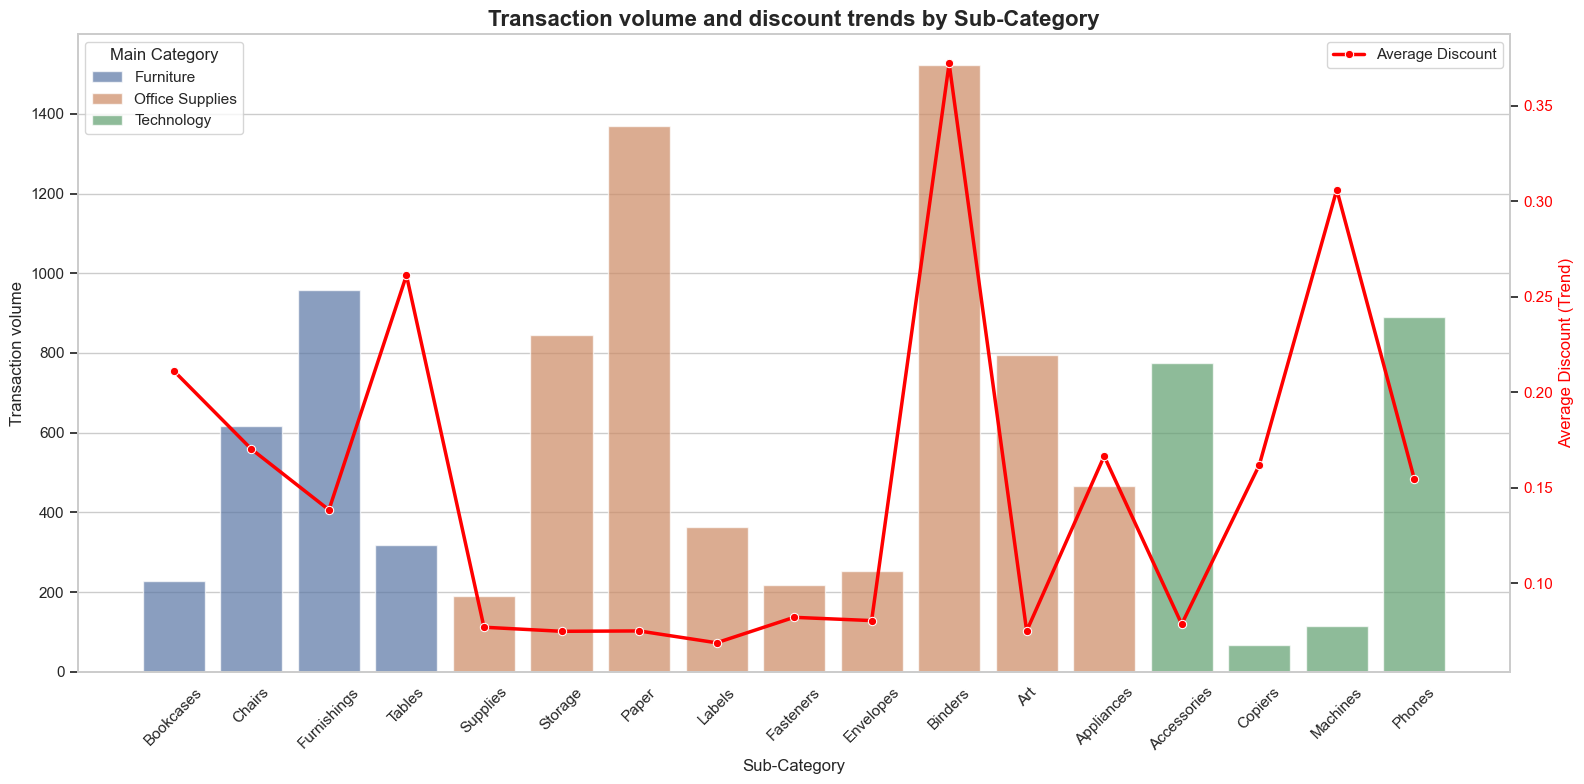

In [18]:
sub_cat_stats = data.groupby(['Category', 'Sub-Category']).agg(
    Count=('Sub-Category', 'count'),
    Avg_Discount=('Discount', 'mean')
).reset_index().sort_values('Category')

fig, ax1 = plt.subplots(figsize=(16, 8))

sns.barplot(
    x='Sub-Category', 
    y='Count', 
    hue='Category', 
    data=sub_cat_stats, 
    ax=ax1, 
    dodge=False, 
    alpha=0.7
)

ax1.set_title('Transaction volume and discount trends by Sub-Category', fontsize=16, fontweight='bold')
ax1.set_xlabel('Sub-Category', fontsize=12)
ax1.set_ylabel('Transaction volume', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title='Main Category', loc='upper left')

ax2 = ax1.twinx()
sns.lineplot(
    x='Sub-Category', 
    y='Avg_Discount', 
    data=sub_cat_stats, 
    ax=ax2, 
    color='red', 
    marker='o', 
    linewidth=2.5, 
    label='Average Discount',
    sort=False 
)

ax2.set_ylabel('Average Discount (Trend)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False) 

plt.tight_layout()
plt.show()

Data reveals that the 'Furniture' category consistently offers the highest average discounts across both high-volume and low-volume products. In contrast, 'Office Supplies' exhibits extreme discount variations for its two best-selling items, while maintaining minimal to no discounts for the rest of its catalog. A notable anomaly is observed in 'Technology,' where the highest discounts are applied to low-volume products. This is counter-intuitive, as higher discounts typically drive higher sales volumes; however, it is likely due to the nature of 'Machines'—high-value items with naturally lower purchase frequencies. Ultimately, the high profitability of the Technology sector is likely driven by the fact that its top-selling products maintain relatively low average discounts.

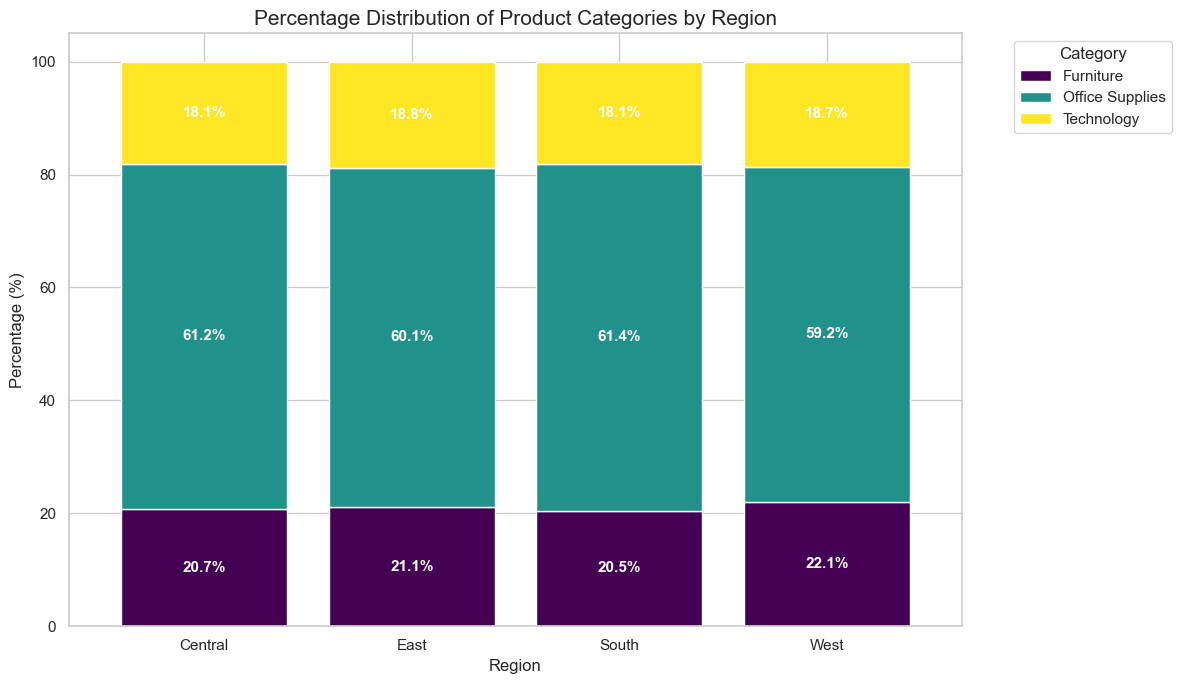

In [19]:
cross_tab = pd.crosstab(data['Region'], data['Category'])

cross_tab_prop = cross_tab.div(cross_tab.sum(1).astype(float), axis=0) * 100


ax = cross_tab_prop.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', width=0.8)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:  
        x, y = p.get_xy() 
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height/2), 
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Percentage Distribution of Product Categories by Region', fontsize=15)
plt.ylabel('Percentage (%)')
plt.xlabel('Region')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Product categories are uniformly distributed across all four regions. This indicates that the choice of merchandise is not a contributing factor to the Central region's inefficiency.

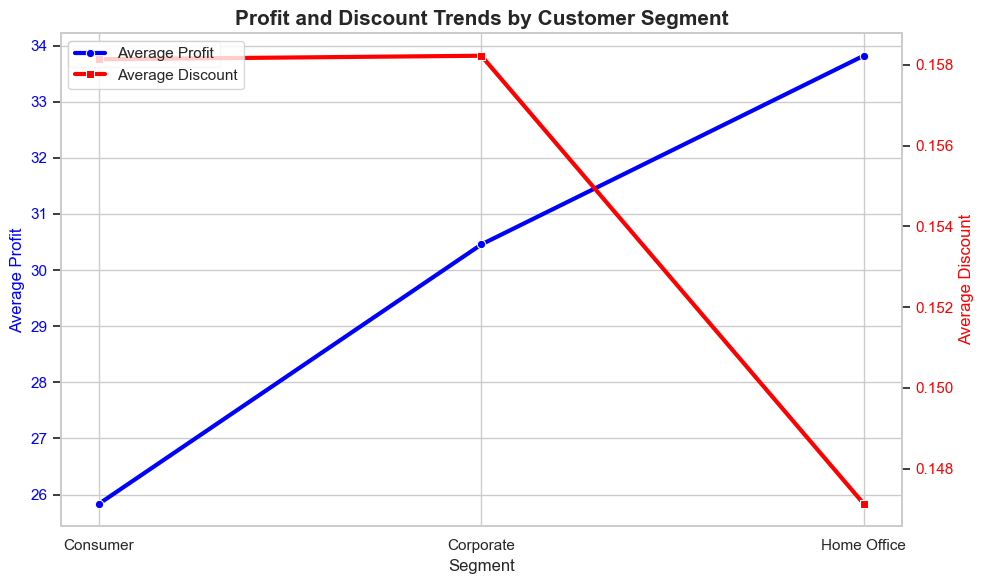

In [20]:
segment_stats = data.groupby('Segment').agg({
    'Profit': 'mean',
    'Discount': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

sns.lineplot(x='Segment', y='Profit', data=segment_stats, ax=ax1, 
             color='blue', marker='o', linewidth=3, label='Average Profit')
ax1.set_ylabel('Average Profit', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('Profit and Discount Trends by Customer Segment', fontsize=15, fontweight='bold')

ax2 = ax1.twinx()
sns.lineplot(x='Segment', y='Discount', data=segment_stats, ax=ax2, 
             color='red', marker='s', linewidth=3, label='Average Discount')
ax2.set_ylabel('Average Discount', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

ax2.grid(False)
plt.tight_layout()
plt.show()

In [21]:
segment_summary = data.groupby('Segment').agg({
    'Profit': ['mean'],
    'Discount': ['mean'],
    'Sales': 'mean',
    'Quantity': 'mean'
}).round(2)

segment_summary.columns = ['_'.join(col).strip() for col in segment_summary.columns.values]

print("Detailed Statistics by Segment:")
print(segment_summary)

Detailed Statistics by Segment:
             Profit_mean  Discount_mean  Sales_mean  Quantity_mean
Segment                                                           
Consumer           25.84           0.16      223.73           3.76
Corporate          30.46           0.16      233.82           3.84
Home Office        33.82           0.15      240.97           3.78


Strategic Segment Hierarchy:
1. Home Office
2. Corporate
3. Segment

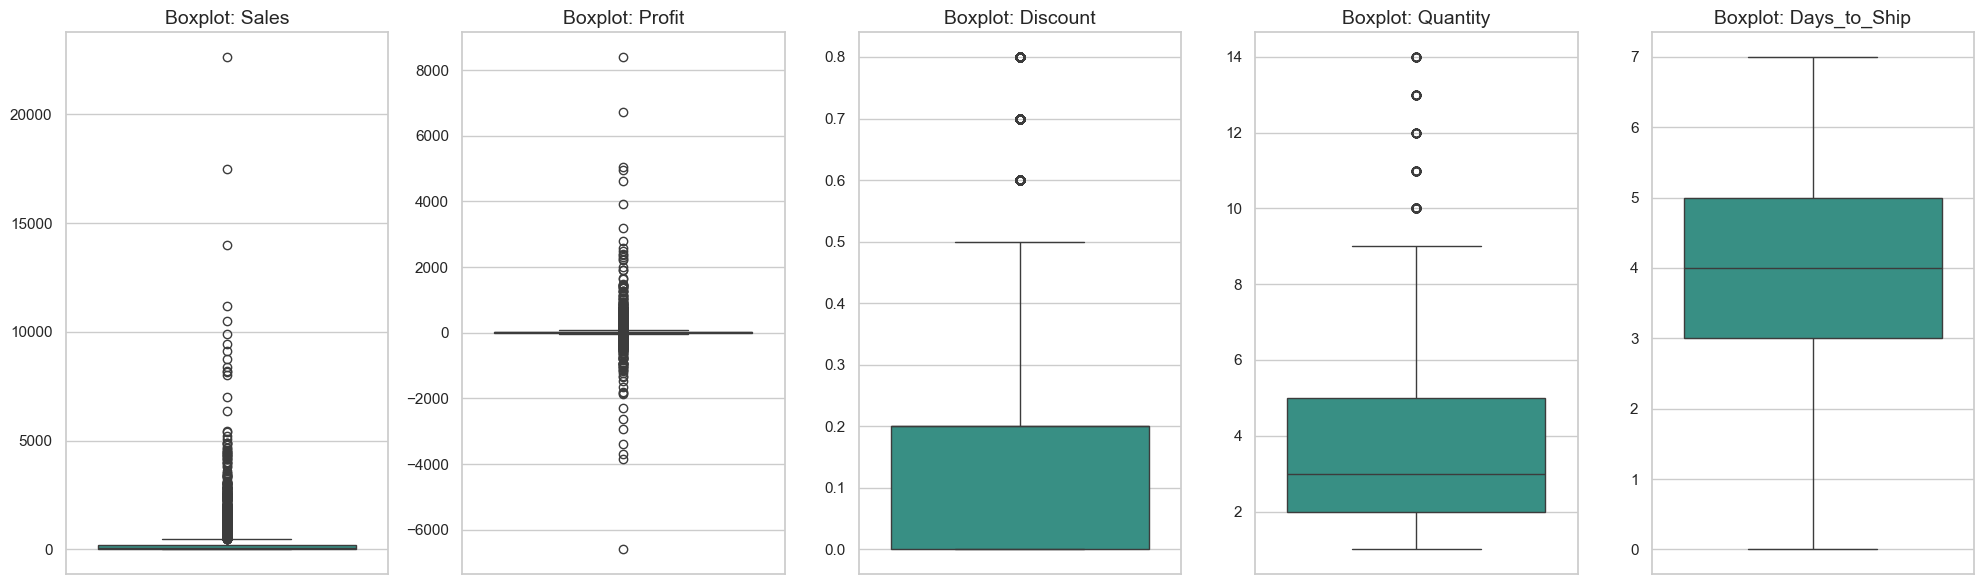

In [23]:
numeric_cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Days_to_Ship']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 6))

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='#2a9d8f')
    axes[i].set_title(f'Boxplot: {col}', fontsize=14)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

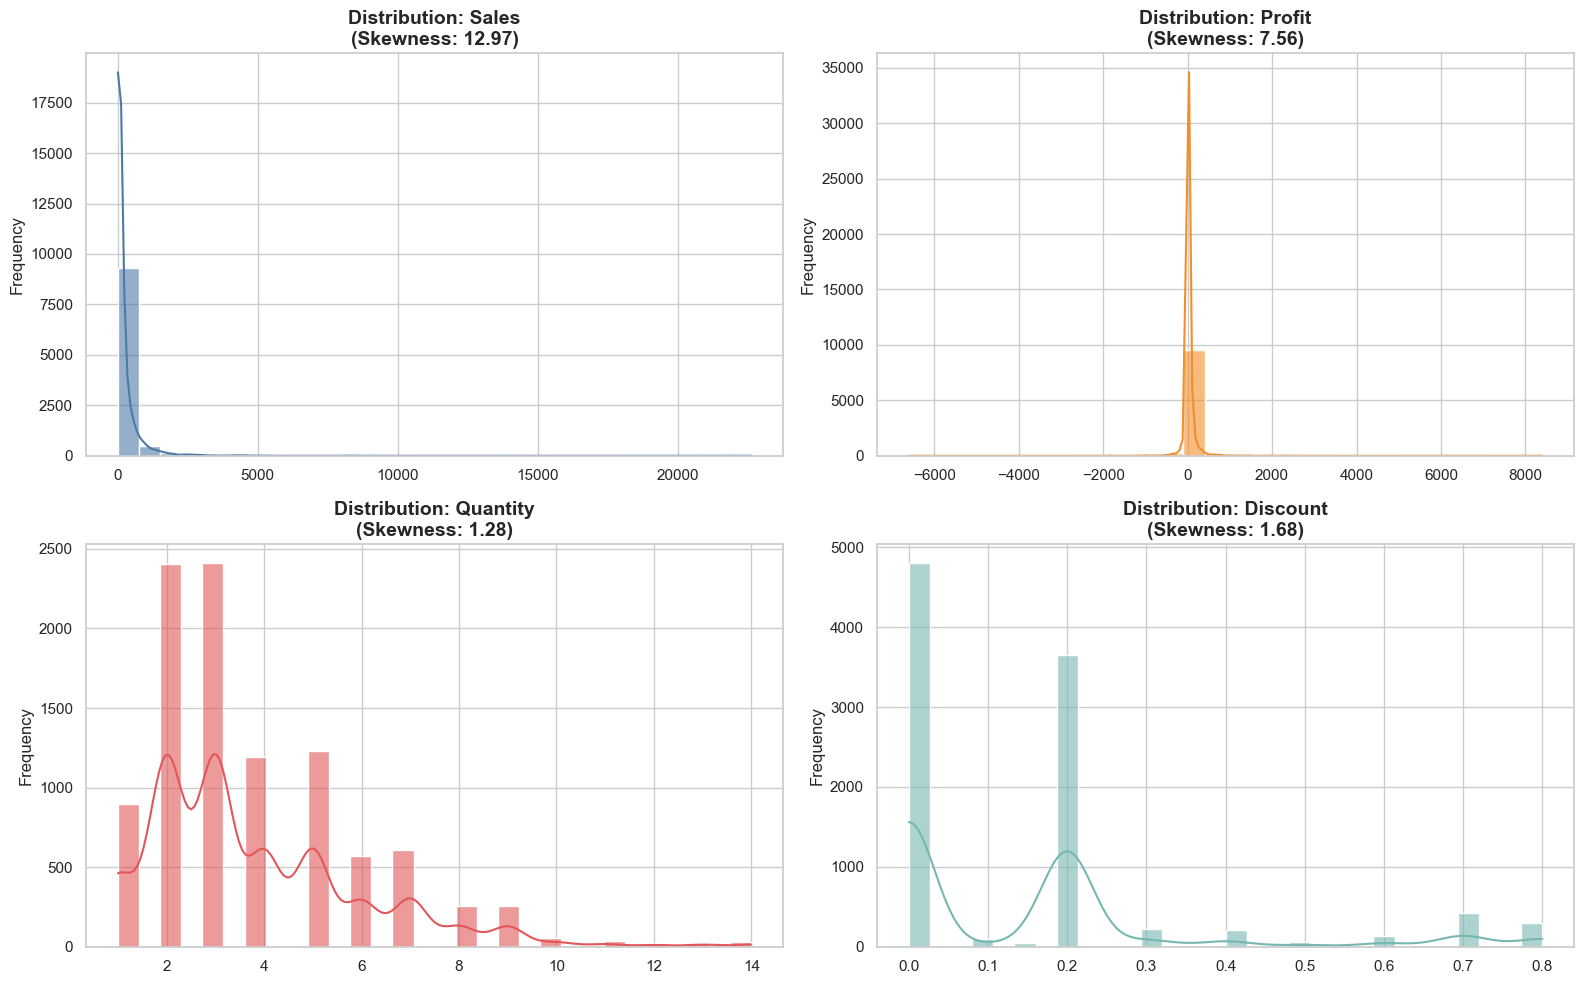

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

cols = ['Sales', 'Profit', 'Quantity', 'Discount']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i + 1)
    
    sns.histplot(data[col], kde=True, color=colors[i], bins=30, alpha=0.6)
    
    skew_val = data[col].skew()
    
    ax.set_title(f'Distribution: {col}\n(Skewness: {skew_val:.2f})', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

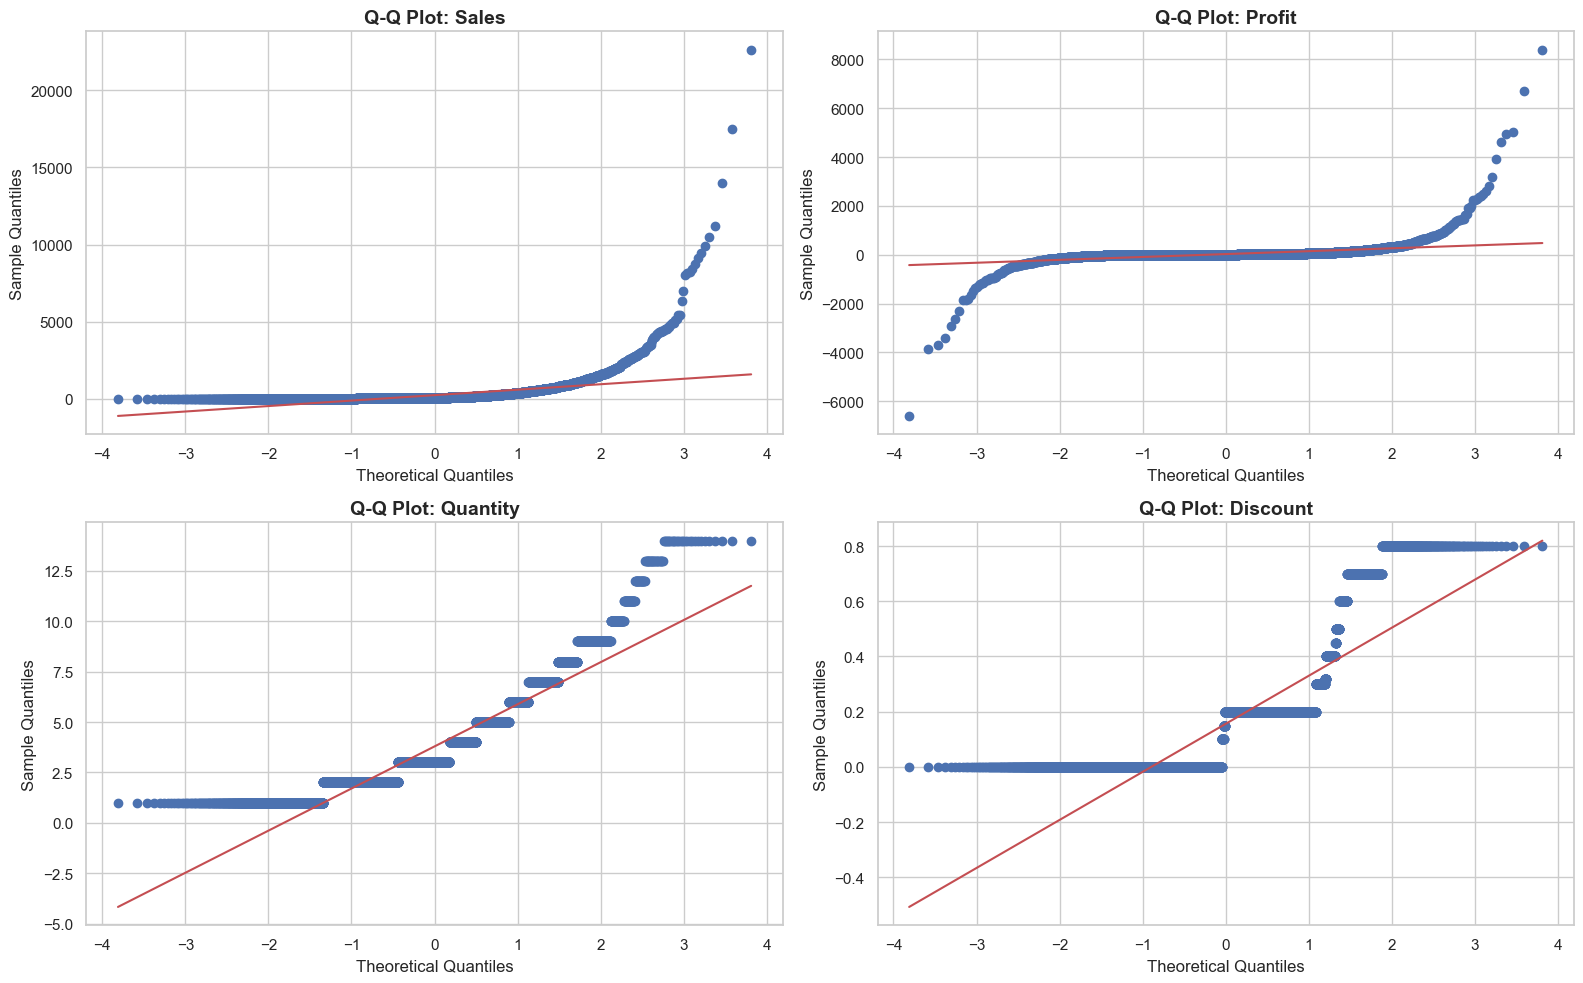

In [25]:
plt.figure(figsize=(16, 10))

cols = ['Sales', 'Profit', 'Quantity', 'Discount']

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i + 1)
    
    stats.probplot(data[col], dist="norm", plot=plt)
    
    ax.set_title(f'Q-Q Plot: {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

## Normalization and Outlier Detection

Based on the Q-Q plots and skewness values exceeding 1, I will apply the Box-Cox transformation to normalize the distributions. However, this method will not be applied to the 'Profit' variable, as it contains negative values. For Profit, an alternative approach (cube square) will be considered to handle the data range while addressing its skewness.

In [26]:
data_transactions = data.copy()

profit_min_abs = abs(data_transactions['Profit'].min()) + 1
data_transactions['Profit_trans'] = np.sign(data['Profit']) * np.power(np.abs(data['Profit']), 1/3)

for col in ['Sales', 'Quantity', 'Discount']:
    data_transactions[f'{col}_trans'], _ = stats.boxcox(data_transactions[col] + 0.001)

new_stats = data_transactions[[f'{c}_trans' for c in ['Sales', 'Profit', 'Quantity', 'Discount']]].agg(['skew', 'kurtosis','mean','std','min']).T
print("Post-Hybrid Transformation Statistics:")
print(new_stats)


Post-Hybrid Transformation Statistics:
                    skew  kurtosis      mean       std        min
Sales_trans     0.016074 -0.583856  3.664132  1.335703  -0.826136
Profit_trans   -0.738572  3.095932  1.672131  2.881464 -18.757754
Quantity_trans -0.007714 -0.394632  1.256597  0.656240   0.001000
Discount_trans -0.022133 -1.914226 -3.873613  2.664029  -6.620804


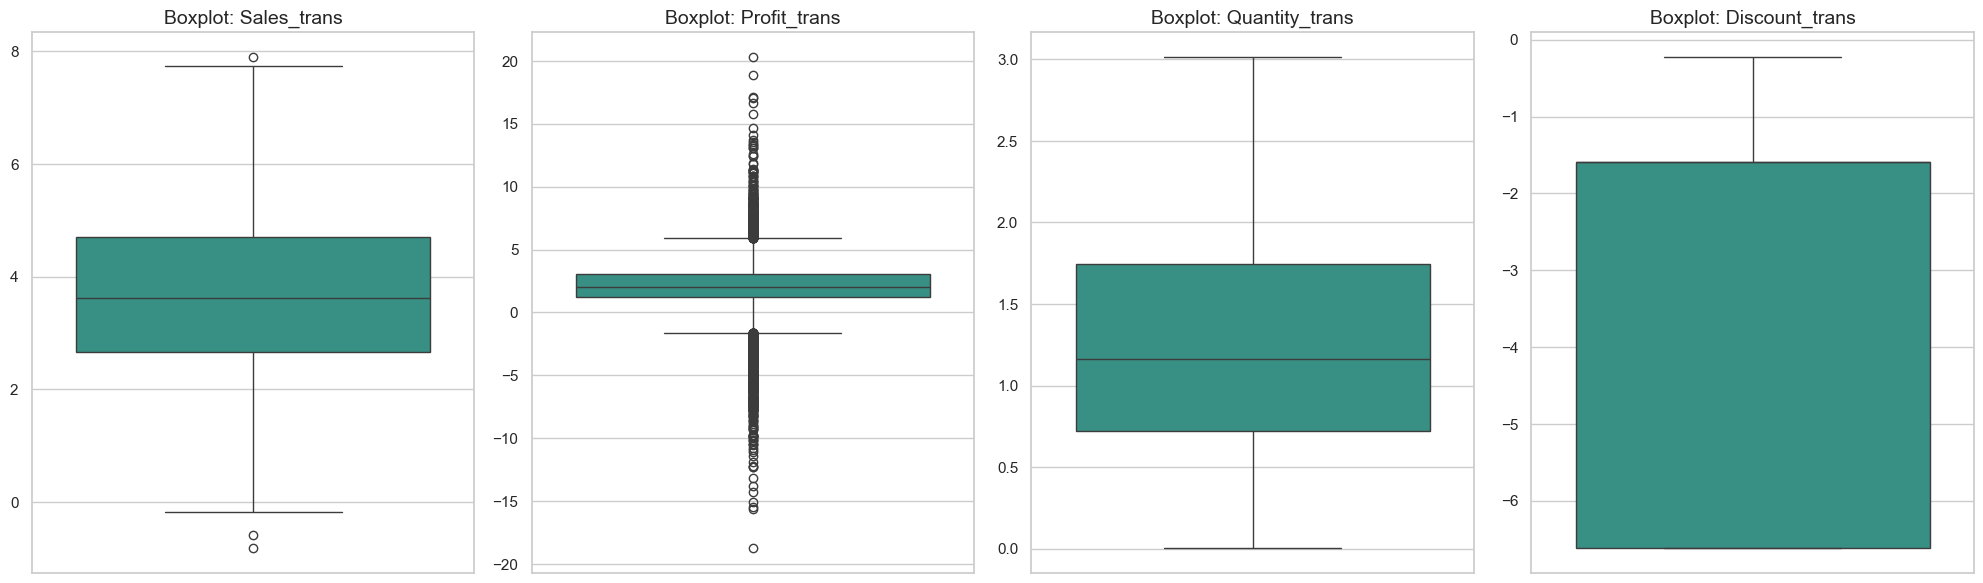

In [27]:
transformed_numeric_cols = ['Sales_trans', 'Profit_trans', 'Quantity_trans', 'Discount_trans']

fig, axes = plt.subplots(1, len(transformed_numeric_cols), figsize=(20, 6))

for i, col in enumerate(transformed_numeric_cols):
    sns.boxplot(y=data_transactions[col], ax=axes[i], color='#2a9d8f')
    axes[i].set_title(f'Boxplot: {col}', fontsize=14)
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

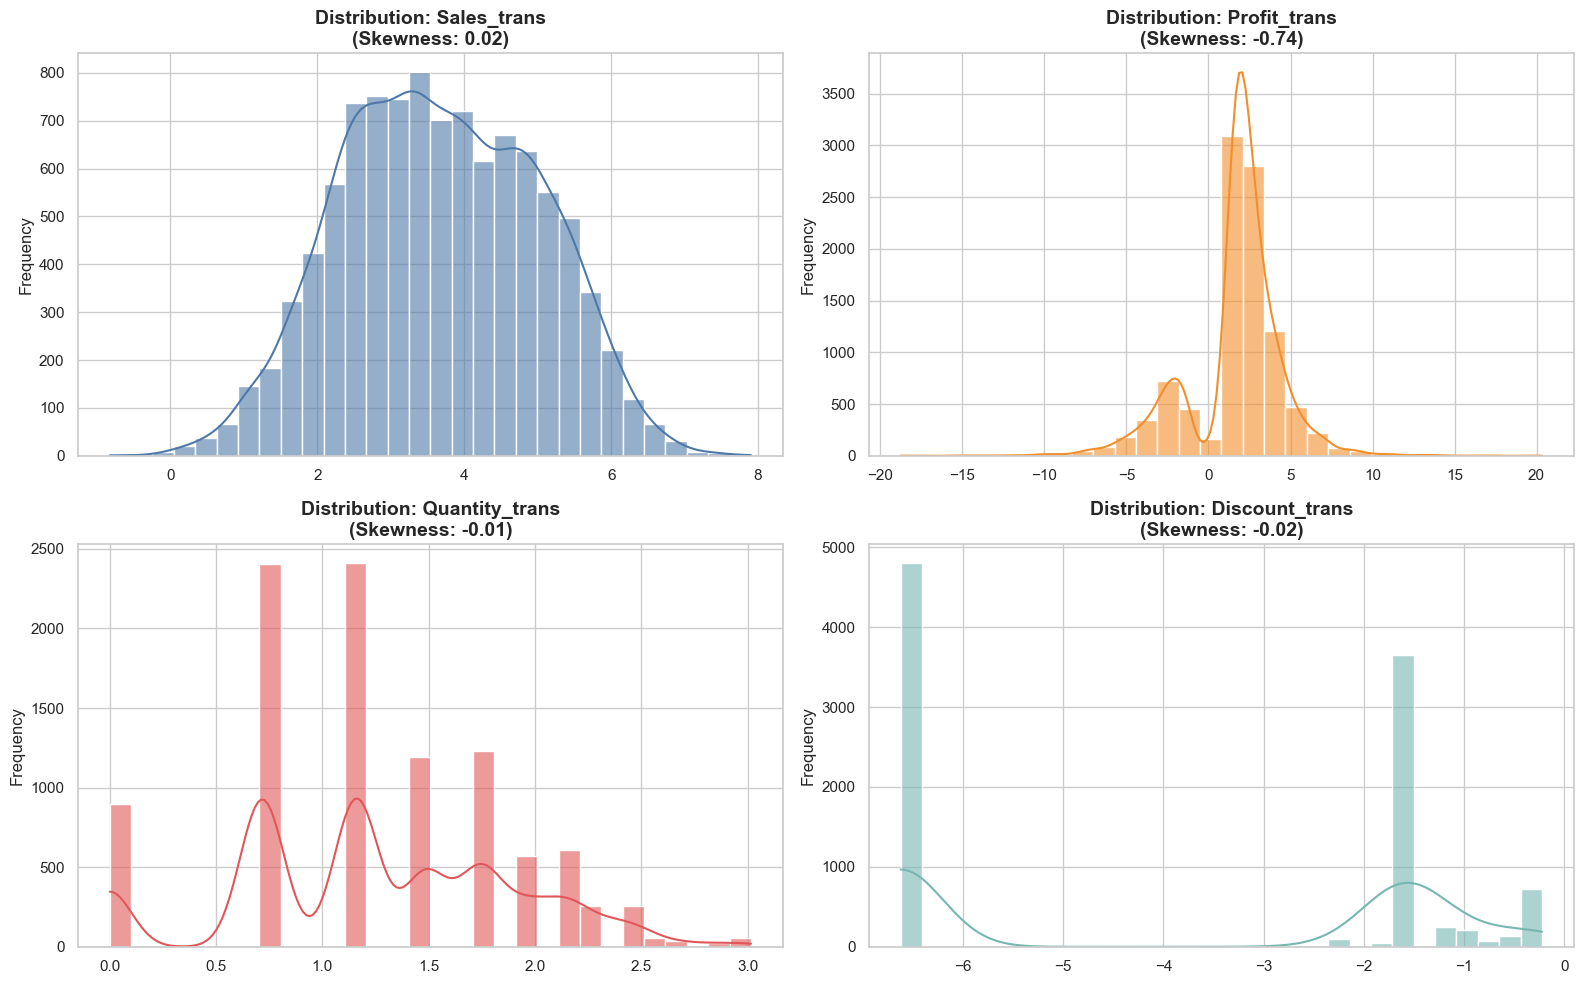

In [28]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10))

cols = ['Sales_trans', 'Profit_trans', 'Quantity_trans', 'Discount_trans']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i + 1)
    
    sns.histplot(data_transactions[col], kde=True, color=colors[i], bins=30, alpha=0.6)
    
    skew_val = data_transactions[col].skew()
    
    ax.set_title(f'Distribution: {col}\n(Skewness: {skew_val:.2f})', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

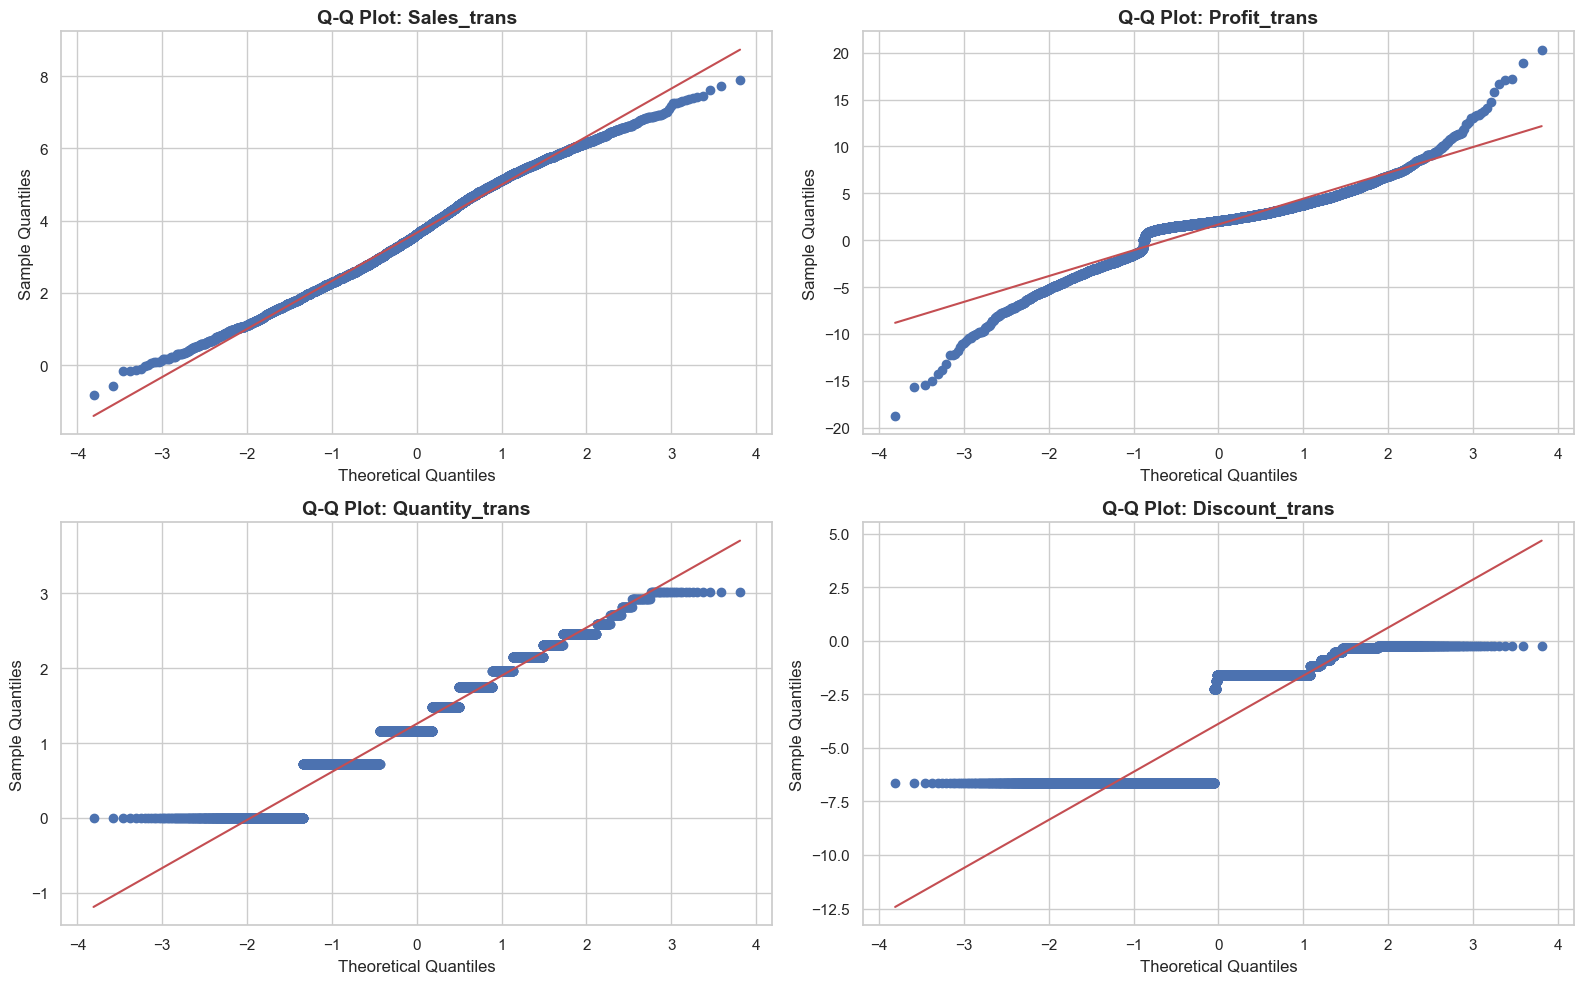

In [29]:
plt.figure(figsize=(16, 10))

cols = ['Sales_trans', 'Profit_trans', 'Quantity_trans', 'Discount_trans']

for i, col in enumerate(cols):
    ax = plt.subplot(2, 2, i + 1)
    
    stats.probplot(data_transactions[col], dist="norm", plot=plt)
    
    ax.set_title(f'Q-Q Plot: {col}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()

The hybrid transformation successfully reduced skewness, resulting in a more normal distribution across the dataset. In the 'Sales' column, the number of 'true' outliers has been minimized. Notably, 'Discount' and 'Quantity' no longer exhibit outliers; this is logically consistent, as values like a 70% discount or a quantity of 10 are realistic business occurrences that provide critical signals for sales analysis and should not be removed. 'Profit' has retained a high kurtosis and standard deviation compared to other features. This is expected, as significant losses and high profits carry specific weight that must remain visible for clustering. The bimodal nature of the Profit distribution—showing distinct negative and positive centers—reflects the actual performance reality and has been preserved for the modeling phase.

## Handling Outliers

Due to the aforementioned reasons—where all recorded cases represent realistic business scenarios that impact sales—I have opted for Winsorization rather than data removal. This technique allows us to cap extreme outliers at specific percentiles, effectively minimizing their disproportionate influence on the model while preserving the integrity and size of the dataset.

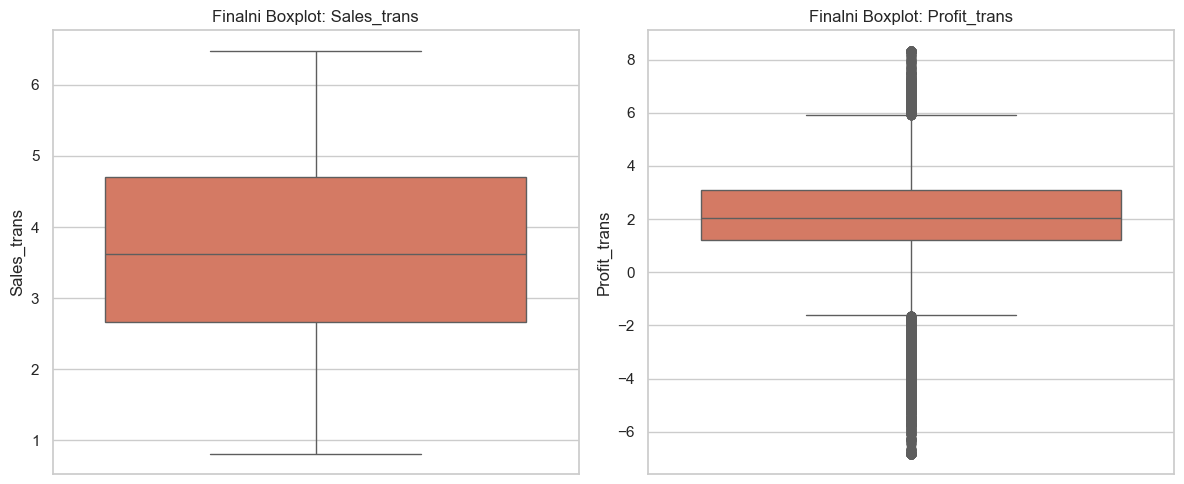

In [30]:
data_final_prep = data_transactions.copy()

cols_to_cap = ['Sales_trans', 'Profit_trans']

for col in cols_to_cap:
    lower_limit = data_final_prep[col].quantile(0.01)
    upper_limit = data_final_prep[col].quantile(0.99)
    
    data_final_prep[col] = data_final_prep[col].clip(lower_limit, upper_limit)


plt.figure(figsize=(12, 5))
for i, col in enumerate(cols_to_cap):
    plt.subplot(1, 2, i + 1)
    sns.boxplot(y=data_final_prep[col], color='#e76f51')
    plt.title(f'Finalni Boxplot: {col}')

plt.tight_layout()
plt.show()

As shown on the Y-axis, the outliers have been successfully compressed.

In [31]:
data_final_prep.head()

,Order ID,Ship Mode,Customer ID,Segment,City,State,Region,Product ID,Category,Sub-Category,...,Discount,Profit,Month,Year,Days_to_Ship,Order_Season,Profit_trans,Sales_trans,Quantity_trans,Discount_trans
0,CA-2016-152156,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,...,0.00,41.9136,11,2016,3,Fall,3.473641,4.866320,0.718027,-6.620804
1,CA-2016-152156,Second Class,CG-12520,Consumer,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,...,0.00,219.5820,11,2016,3,Fall,6.032985,5.626647,1.160976,-6.620804
2,CA-2016-138688,Second Class,DV-13045,Corporate,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,...,0.00,6.8714,6,2016,4,Summer,1.901144,2.511892,0.718027,-6.620804
3,US-2015-108966,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,...,0.45,-383.0310,10,2015,7,Fall,-6.834662,5.819182,1.745030,-0.792378
4,US-2015-108966,Standard Class,SO-20335,Consumer,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,...,0.20,2.5164,10,2015,7,Fall,1.360170,2.880311,0.718027,-1.588630


## Dimensionality Reduction

In [32]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

result = cramers_v(data['State'], data['City'])
print(f"Cramér's V povezanost između State i City: {result:.4f}")

Cramér's V povezanost između State i City: 0.8758


In [33]:
result = cramers_v(data['Category'], data['Sub-Category'])
print(f"Cramér's V povezanost između Category i Sub-Category: {result:.4f}")

Cramér's V povezanost između Category i Sub-Category: 0.9993


In [34]:
result = cramers_v(data['Product Name'], data['Sub-Category'])
print(f"Cramér's V povezanost između Product Name i Sub-Category: {result:.4f}")

Cramér's V povezanost između Product Name i Sub-Category: 0.9035


In [35]:
result = cramers_v(data['Product Name'], data['Category'])
print(f"Cramér's V povezanost između Product Name i Category: {result:.4f}")

Cramér's V povezanost između Product Name i Category: 0.9028


In [36]:
result = cramers_v(data['State'], data['Region'])
print(f"Cramér's V povezanost između State i Region: {result:.4f}")

Cramér's V povezanost između State i Region: 0.9977


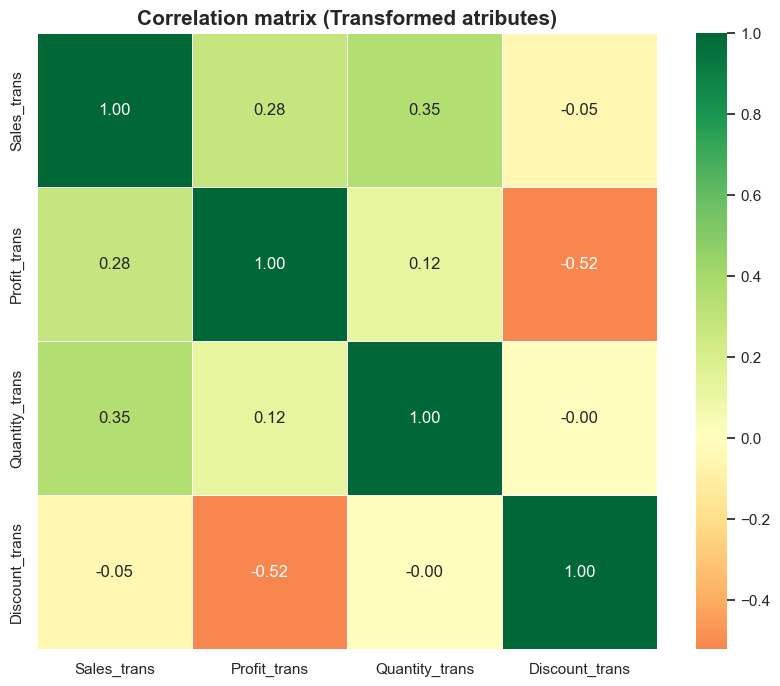

In [37]:
numerical_columns = ['Sales_trans', 'Profit_trans', 'Quantity_trans', 'Discount_trans']

corr_matrix = data_final_prep[numerical_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='RdYlGn', 
    linewidths=0.5,
    center=0
)

plt.title('Correlation matrix (Transformed atributes)', fontsize=15, fontweight='bold')
plt.show()

There is a strong negative correlation (-0.51) between Discount and Profit, confirming that higher discounts lead to significantly lower profit margins.

In [38]:
data_final_prep = data_final_prep.drop(['Order ID','Customer ID','Ship Mode','City','State','Product ID','Sub-Category','Discount','Profit','Month','Year','Order_Season','Quantity','Sales','Product Name'], axis = 1)

## Encoding of Categorical Columns

In [39]:
segment_map = {
    'Home Office': 2,
    'Corporate': 1,
    'Consumer': 0
}

data_final_prep['Segment_enc'] = data_final_prep['Segment'].map(segment_map)


print(data_final_prep[['Segment', 'Segment_enc']].drop_duplicates().sort_values('Segment_enc', ascending=False))

        Segment  Segment_enc
14  Home Office            2
2     Corporate            1
0      Consumer            0


In [40]:
data_final_prep = data_final_prep.drop(['Segment'], axis = 1)

In [41]:
data_final_prep.head()


,Region,Category,Days_to_Ship,Profit_trans,Sales_trans,Quantity_trans,Discount_trans,Segment_enc
0,South,Furniture,3,3.473641,4.866320,0.718027,-6.620804,0
1,South,Furniture,3,6.032985,5.626647,1.160976,-6.620804,0
2,West,Office Supplies,4,1.901144,2.511892,0.718027,-6.620804,1
3,South,Furniture,7,-6.834662,5.819182,1.745030,-0.792378,0
4,South,Office Supplies,7,1.360170,2.880311,0.718027,-1.588630,0


In [42]:
region_map = {
    'Central': 0,
    'South': 1,
    'East': 2,
    'West': 3
}

category_map = {
    'Furniture': 0,
    'Office Supplies': 1,
    'Technology': 2
}

data_final_prep['Region_enc'] = data_final_prep['Region'].map(region_map)
data_final_prep['Category_enc'] = data_final_prep['Category'].map(category_map)



In [43]:
data_final_prep = data_final_prep.drop(['Region','Category'], axis = 1)


## Final dataset scaling

In [44]:
scaler = RobustScaler()
data_final_prep_scaled = scaler.fit_transform(data_final_prep)

data_final_prep_scaled = pd.DataFrame(
    data_final_prep_scaled, 
    columns=data_final_prep.columns
)


data_final_prep_scaled.head()

,Days_to_Ship,Profit_trans,Sales_trans,Quantity_trans,Discount_trans,Segment_enc,Region_enc,Category_enc
0,-0.5,0.753112,0.607557,-0.431302,-1.000000,0.0,-0.5,-1.0
1,-0.5,2.110894,0.980313,0.000000,-1.000000,0.0,-0.5,-1.0
2,0.0,-0.081128,-0.546719,-0.431302,-1.000000,1.0,0.5,0.0
3,1.5,-4.715646,1.074705,0.568698,0.158232,0.0,-0.5,-1.0
4,1.5,-0.368126,-0.366099,-0.431302,0.000000,0.0,-0.5,0.0


The cleaned and transformed dataset now incorporates three core dimensions: the Logistics factor, the Financial factor, and the Business factor.

## Finding the Optimal Number of Clusters (K)

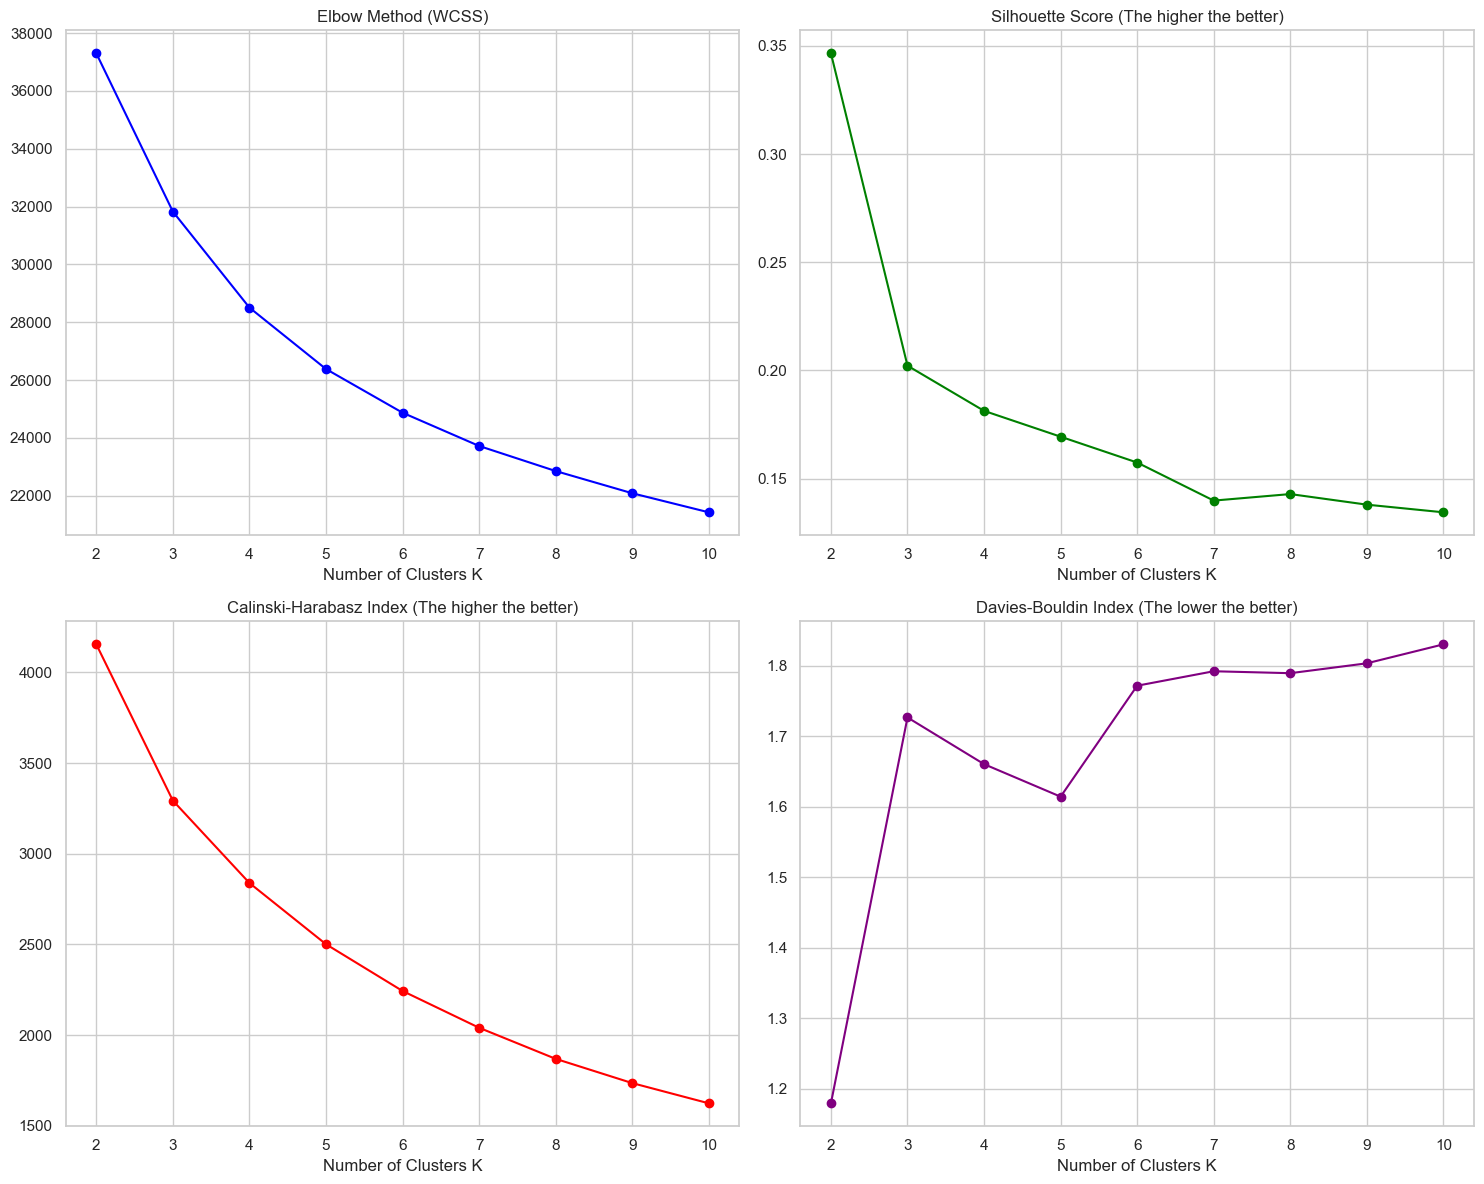

In [45]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

wcss = []
silhouette_avg = []
calinski_harabasz = []
davies_bouldin = []
k_range = range(2, 11) 


for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_final_prep_scaled)
    
    wcss.append(kmeans.inertia_)
    
    silhouette_avg.append(silhouette_score(data_final_prep_scaled, labels))
    
    calinski_harabasz.append(calinski_harabasz_score(data_final_prep_scaled, labels))
    
    davies_bouldin.append(davies_bouldin_score(data_final_prep_scaled, labels))

fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Elbow Method
axs[0, 0].plot(range(2, 11), wcss, marker='o', color='blue')
axs[0, 0].set_title('Elbow Method (WCSS)')
axs[0, 0].set_xlabel('Number of Clusters K')

# Silhouette Score
axs[0, 1].plot(k_range, silhouette_avg, marker='o', color='green')
axs[0, 1].set_title('Silhouette Score (The higher the better)')
axs[0, 1].set_xlabel('Number of Clusters K')

# Calinski-Harabasz
axs[1, 0].plot(k_range, calinski_harabasz, marker='o', color='red')
axs[1, 0].set_title('Calinski-Harabasz Index (The higher the better)')
axs[1, 0].set_xlabel('Number of Clusters K')

# Davies-Bouldin
axs[1, 1].plot(k_range, davies_bouldin, marker='o', color='purple')
axs[1, 1].set_title('Davies-Bouldin Index (The lower the better)')
axs[1, 1].set_xlabel('Number of Clusters K')

plt.tight_layout()
plt.show()

Although statistical metrics—such as the Silhouette Score and Elbow Method—suggest that $K=2$ is the optimal number of clusters, I have decided to proceed with $K=3$. Based on the previously observed visual patterns and business logic, $K=3$ likely provides a more nuanced and actionable segmentation. To validate this decision, I will visualize and compare the results for $K=2$, $K=3$, and $K=4$ to evaluate which model best captures the underlying business dynamics.

## Clustering

In [46]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.cluster import HDBSCAN

kmeans = KMeans(n_clusters=3, random_state=17, n_init=10)
data_final_prep['KMeans_Labels'] = kmeans.fit_predict(data_final_prep_scaled)

hierarchical = AgglomerativeClustering(n_clusters=3)
data_final_prep['Hierarchical_Labels'] = hierarchical.fit_predict(data_final_prep_scaled)


hdbscan = HDBSCAN(min_cluster_size=30, min_samples=10, store_centers='centroid')
data_final_prep['HDBSCAN_Labels'] = hdbscan.fit_predict(data_final_prep_scaled)



In [47]:
data['KMeans_Labels'] = data_final_prep['KMeans_Labels']
data['Hierarchical_Labels'] = data_final_prep['Hierarchical_Labels']
data['HDBSCAN_Labels'] = data_final_prep['HDBSCAN_Labels']

def get_real_profile(df, label_col):
    
    return df.groupby(label_col).agg({
        'Profit': 'mean',
        'Sales': 'mean',
        'Discount': 'mean',
        'Quantity': 'mean',
        'Order ID': 'count' 
    }).rename(columns={'Order ID': 'Count'}).round(2)

print("--- K-MEANS: ---")
print(get_real_profile(data, 'KMeans_Labels'))

print("\n--- HIJERARHIJSKI: ---")
print(get_real_profile(data, 'Hierarchical_Labels'))

print("\n--- HDBSCAN: ---")
print(get_real_profile(data, 'HDBSCAN_Labels'))

--- K-MEANS: ---
               Profit   Sales  Discount  Quantity  Count
KMeans_Labels                                           
0              -83.05  254.56      0.48      3.78   1880
1                9.64   48.76      0.09      3.23   5502
2              149.11  593.55      0.07      4.98   2612

--- HIJERARHIJSKI: ---
                     Profit    Sales  Discount  Quantity  Count
Hierarchical_Labels                                            
0                     26.23   136.19      0.08      3.65   7360
1                    -83.23   252.47      0.48      3.76   1876
2                    329.09  1083.40      0.05      5.19    758

--- HDBSCAN: ---
                Profit   Sales  Discount  Quantity  Count
HDBSCAN_Labels                                           
-1               57.80  508.49      0.20      4.31   2745
 0              -46.82  293.20      0.32      3.22     32
 1               18.06   73.50      0.03      3.19     90
 2               97.13  322.29      0.00      

1. K-Means Clustering ($K=3$):<br>
Cluster 0 (Critical Loss): High discount, high volume, negative profit (18% of samples). These transactions are value-destructive and should be minimized or eliminated.
<br>Cluster 1 (Standard Operations): Low discount, low volume, low profit (55% of samples). This represents the core "baseline" of regular, everyday transactions.
<br>Cluster 2 (High-Value Growth): Low discount, very high volume, high profit (26% of samples). These are the most valuable transactions; the goal is to scale this segment as they drive profitability without relying on discounts.<br>
<br>
2. Hierarchical Clustering: <br>
Cluster 0 (Regular Transactions): Low discount, moderate volume, low profit (74%). Corresponds to K-Means Cluster 1.<br>
Cluster 1 (Discount-Driven Loss): High discount, high volume, negative profit (18%). Precisely matches the 18% identified by K-Means, highlighting a consistent problematic segment.<br>
Cluster 2 (Premium Performers): Low discount, maximum volume, high profit (8%). A more exclusive, high-performing group compared to K-Means Cluster 2.<br>
<br>
3. HDBSCANResult: Produced 25 clusters plus a significant noise (outlier) cluster.<br>
<br>Conclusion: The output is non-interpretable for business strategy. The high granularity makes it impossible to derive actionable insights compared to the more stable K-Means and Hierarchical models.

### New test for HDBSCAN

In [48]:
hdbscan = HDBSCAN(min_cluster_size=400, min_samples=50, cluster_selection_epsilon=0.1, store_centers='centroid')

data_final_prep['HDBSCAN_Labels_V2'] = hdbscan.fit_predict(data_final_prep_scaled)

data['HDBSCAN_Labels_V2'] = data_final_prep['HDBSCAN_Labels_V2']



In [49]:
print("\n--- HDBSCAN_V2: REALNI PROFIL ---")
print(get_real_profile(data, 'HDBSCAN_Labels_V2'))


--- HDBSCAN_V2: REALNI PROFIL ---
                   Profit   Sales  Discount  Quantity  Count
HDBSCAN_Labels_V2                                           
-1                  34.79  306.34      0.19      3.87   7084
 0                  17.47   52.40      0.00      3.64   1277
 1                  12.90   39.59      0.08      3.56    898
 2                   8.24   33.45      0.20      3.56    735


HDBSCAN:<br>



Labels 0 and 1: Fairly identical clusters across all parameters, with no discounts/low sales/low profit – they resemble the regular users from K-Means and Hierarchical clustering. <br>



Label 2: Low discount/low sales/low profit – this is a new group of transactions that could very easily be merged with the previous two labels. <br>



Label -1 Outliers: The algorithm classified the largest number of transactions as outliers, characterized by low discounts/high sales/low profit. Based on the average values and count, I would say the algorithm placed all those high positive and negative profit values here, which is why the average values appear so moderate.

------------

I have considered comparing the methods using the Dunn Index, but due to the high number of extreme values, I decided against it.

-------------------

### MeanShift

In [51]:
from sklearn.cluster import MeanShift, estimate_bandwidth

ms = MeanShift(bandwidth=1.50, bin_seeding=True)
data['MeanShift_Labels'] = ms.fit_predict(data_final_prep_scaled)

def get_ms_profile(df, label_col):
    return df.groupby(label_col).agg({
        'Profit': 'mean',
        'Sales': 'mean',
        'Discount': 'mean',
        'Order ID': 'count'
    }).rename(columns={'Order ID': 'Count'}).round(2)

print("\n--- MEANSHIFT: ---")
print(get_ms_profile(data, 'MeanShift_Labels'))


--- MEANSHIFT: ---
                  Profit   Sales  Discount  Count
MeanShift_Labels                                 
0                  55.12  226.71      0.08   8023
1                 -12.32   45.10      0.55    898
2                -150.80  451.45      0.41    955
3                  -6.68   56.68      0.27    118


Label 0: low discount/high sales/solid profit – this is a description of regular transactions, and the algorithm managed to cluster as many as 80% of them. <br>



The algorithm classified the remaining clusters as harmful purchases and even decomposed them into three labels. This is not bad, as it provides insight into a different approach to transaction segmentation where we focus strictly on those with negative profit. However, the downside is that certain groups of transactions we previously identified, which are useful to keep in mind, are ignored. For example, a transaction that brings in a low profit can be a bottleneck and a problem in business regardless of the fact that it is not in our negative clusters. Also, the method "ate" my cluster of significant customers who generate high profit. <br>



Label 1: high discount/low sales/small deficit – here, the small number of sales had an even greater impact on the small deficit than the high discount. <br>



Label 2: high discount/very high sales/large deficit – now that the number of sales is also large, the deficit is large due to the high discount. <br>



Label 3: moderate discount/low sales/small deficit – unlike Label 1, here the smaller discount resulted in a smaller deficit.<br>

### Comparison of K-Means and Hierarchical Clustering

In [52]:
from sklearn.metrics import adjusted_rand_score

ari_kh = adjusted_rand_score(data['KMeans_Labels'], data['Hierarchical_Labels'])
print(f"Similarity between K-Means and Hijerarhijskog (ARI): {ari_kh:.2f}")

ari_km = adjusted_rand_score(data['KMeans_Labels'], data['MeanShift_Labels'])
print(f"Similarity between K-Means and MeanShift (ARI): {ari_km:.2f}")

ari_km = adjusted_rand_score(data['Hierarchical_Labels'], data['MeanShift_Labels'])
print(f"Similarity between Hijerarhijskog and MeanShift (ARI): {ari_km:.2f}")

Similarity between K-Means and Hijerarhijskog (ARI): 0.54
Similarity between K-Means and MeanShift (ARI): 0.41
Similarity between Hijerarhijskog and MeanShift (ARI): 0.70


K-Means and the Hierarchical algorithm, as previously seen in the analysis, are very similar in terms of the cluster logic they identified. However, Hierarchical clustering provided a more precise clustering for large transactions (Label 2), and more importantly, it did not place them in a separate or negative cluster (Label 1), but rather where MeanShift placed them—among normal transactions. These were likely transactions located at the decision boundary between two clusters. <br>

Although MeanShift and Hierarchical are the most similar (ARI 0.70), a significant difference exists: due to its density-based nature, MeanShift grouped everything with high profit into Label 0, while focusing on precisely breaking down losses. On the other hand, Hierarchical clustering remains the only model that successfully recognized both the extremely poor and the extremely good performers, making it the most complete model for this problem.

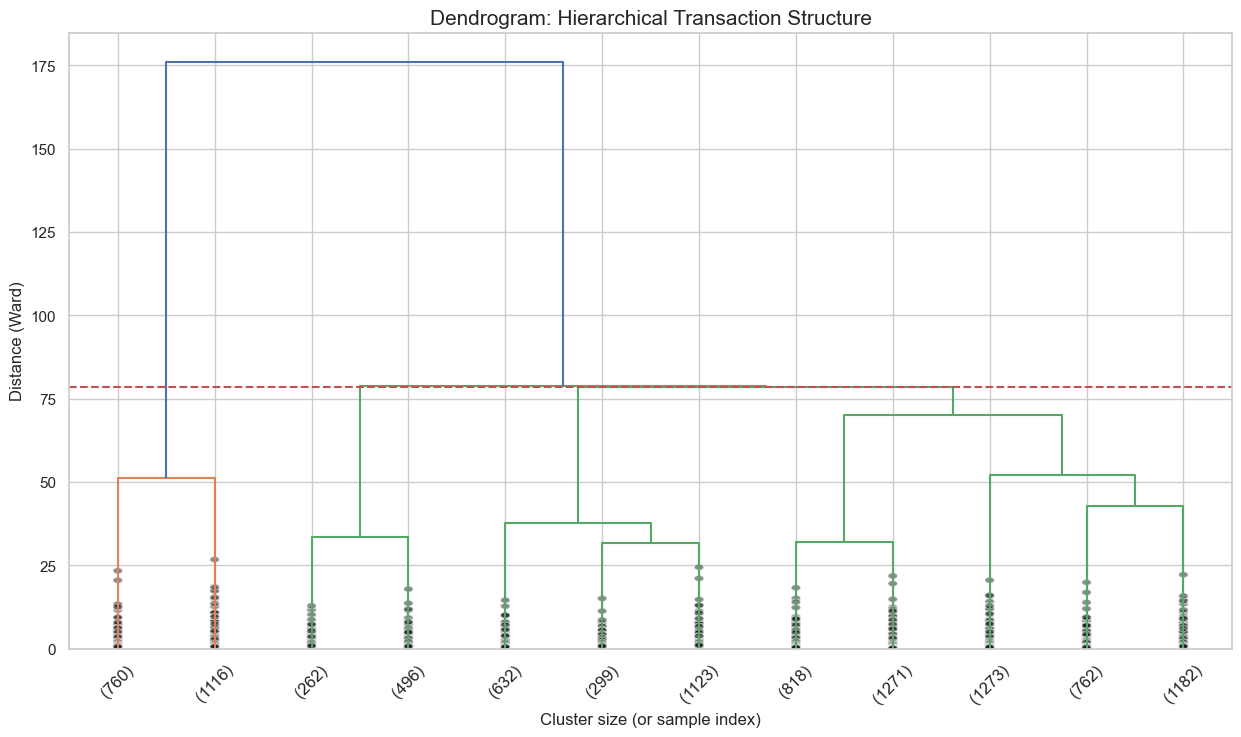

In [53]:
Z = linkage(data_final_prep_scaled, method='ward')

plt.figure(figsize=(15, 8))
plt.title('Dendrogram: Hierarchical Transaction Structure', fontsize=15)
plt.xlabel('Cluster size (or sample index)', fontsize=12)
plt.ylabel('Distance (Ward)', fontsize=12)


dendrogram(
    Z,
    truncate_mode='lastp',  
    p=12,                   
    leaf_rotation=45.,
    leaf_font_size=12.,
    show_contracted=True    
)
plt.axhline(y=78.5, color='r', linestyle='--') 

plt.show()


The dendrogram showed an interesting thing, which is a confirmation of the previously conducted test for finding the optimal number K, where all the algorithms performed gave K=2 as the best solution. However, due to the nature of the task, K=3 was chosen, and just how close the two clusters on the right side actually are is shown by the fact that one cannot clearly see where the horizontal red line intersects the third vertical line. MeanShift, for example, grouped that entire section together.

### PCA Cluster Visualization

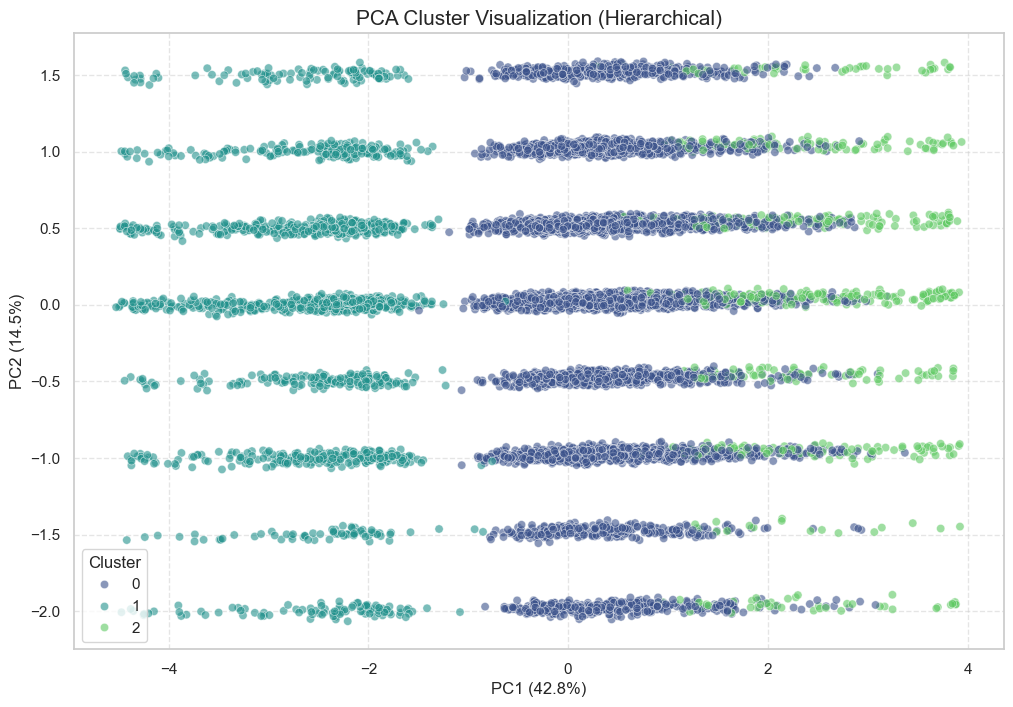

In [55]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_final_prep_scaled)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = data['Hierarchical_Labels'].astype(str) # Koristimo tvoj "pobednički" model

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Cluster', 
    data=pca_df, 
    palette='viridis', 
    alpha=0.6,
    edgecolor='w'
)

plt.title('PCA Cluster Visualization (Hierarchical)', fontsize=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Izvini, moja greška. Evo prve rečenice i celog pasusa isključivo na engleskom:<br>

The PCA visualization graphically confirms that the clusters, accounting for a total of 58.2% of the variance, look exactly as they do in the dendrogram: <br>



Cluster 1 - Separated on the left side as deficit transactions. <br>



Clusters 0 and 2 - clusters of regular and extreme transactions, whose individual points overlap at the boundary. <br>


Since the segmentation by PC1 follows the results obtained so far and carries 42.8% of the variance, this component most likely represents the correlation between profit and discount.

--------------------------

To see why the samples are divided into lines along PC2, I will plot the PCA Loadings:

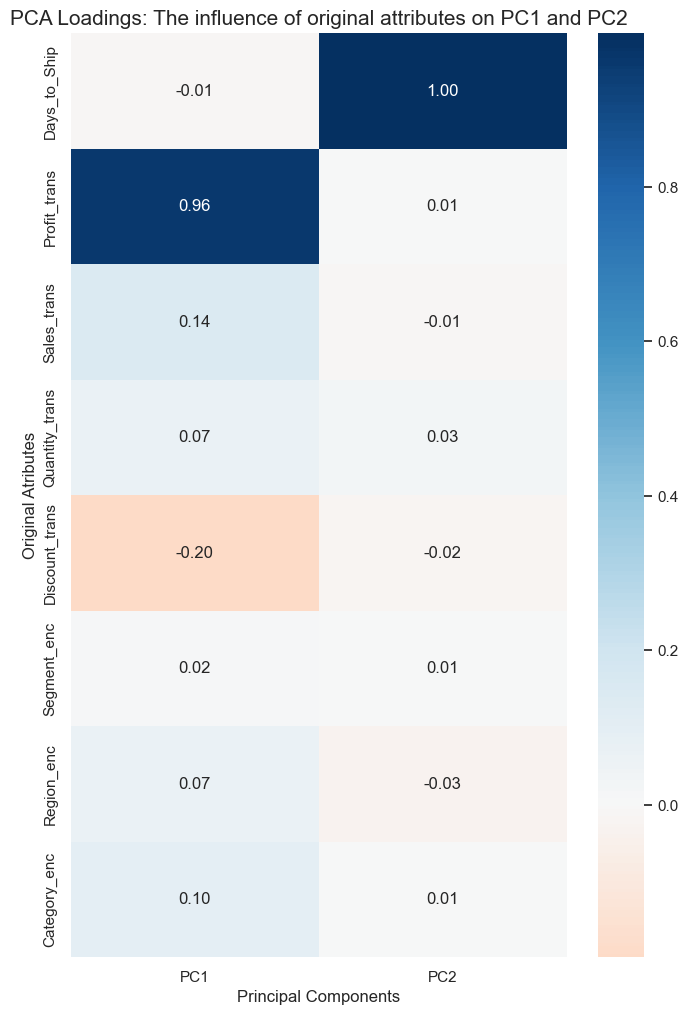

In [56]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=data_final_prep_scaled.columns
)

plt.figure(figsize=(8, 12))  
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0, fmt='.2f')

plt.title('PCA Loadings: The influence of original attributes on PC1 and PC2', fontsize=15)
plt.ylabel('Original Atributes')
plt.xlabel('Principal Components')
plt.show()

PCA Loadings table:
                     PC1       PC2
Days_to_Ship   -0.007805  0.998919
Profit_trans    0.959976  0.005788
Sales_trans     0.143583 -0.010583
Quantity_trans  0.069304  0.028765
Discount_trans -0.196898 -0.015270
Segment_enc     0.016314  0.007766
Region_enc      0.068743 -0.029167
Category_enc    0.095950  0.006645


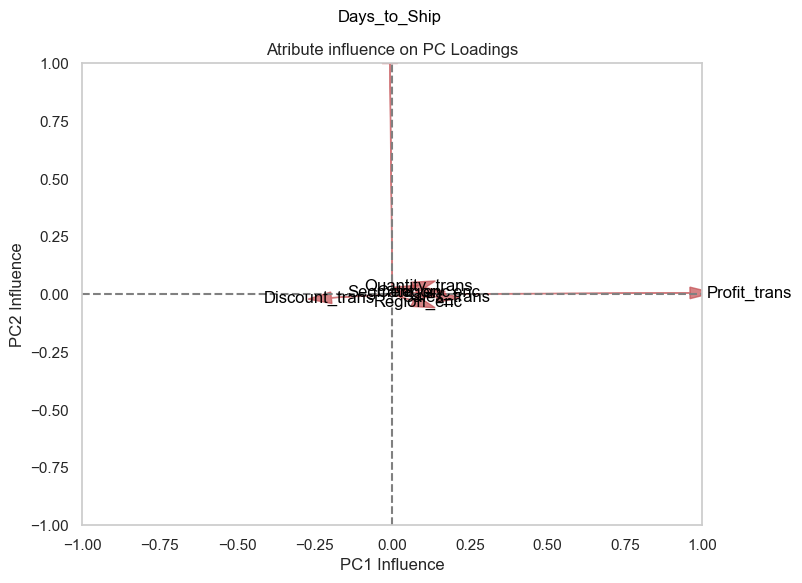

In [58]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=data_final_prep_scaled.columns 
)

print("PCA Loadings table:")
print(loadings)

plt.figure(figsize=(8, 6))
for i, feature in enumerate(loadings.index):
    plt.arrow(0, 0, loadings.PC1[i], loadings.PC2[i], color='r', alpha=0.7, head_width=0.05)
    plt.text(loadings.PC1[i]*1.2, loadings.PC2[i]*1.2, feature, color='black', ha='center', va='center')

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('PC1 Influence')
plt.ylabel('PC2 Influence')
plt.title('Atribute influence on PC Loadings')
plt.grid()
plt.show()

The results for PC2 are actually something I would have never predicted: delivery speed. The division into 8 groups along the y-axis makes sense, as the possible number of delivery days ranges from 0 to 7 (8 values). This is a useful finding because the graph shows that all types of transactions are distributed almost equally across each line of the y-axis, meaning that the number of delivery days does not impact business operations. This also makes sense, as in practice, delivery is most often the responsibility of a separate courier company rather than the company selling the products.

### 3D Plot

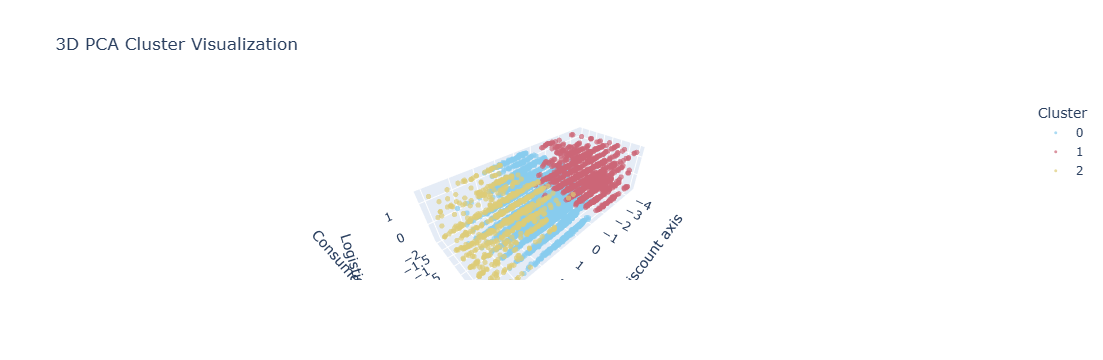

In [59]:
import plotly.express as px

pca_3d = PCA(n_components=3)
pca_data_3d = pca_3d.fit_transform(data_final_prep_scaled)

pca_df_3d = pd.DataFrame(data=pca_data_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['Cluster'] = data['Hierarchical_Labels'].astype(str)

fig = px.scatter_3d(
    pca_df_3d, 
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    title='3D PCA Cluster Visualization',
    labels={'PC1': 'Profit/Discount axis', 'PC2': 'Logistic axis (Days to Ship)', 'PC3': 'Consumer'}, #Consumer as PC3 is added additionally
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Safe
)

fig.update_traces(marker=dict(size=3))

fig.show()

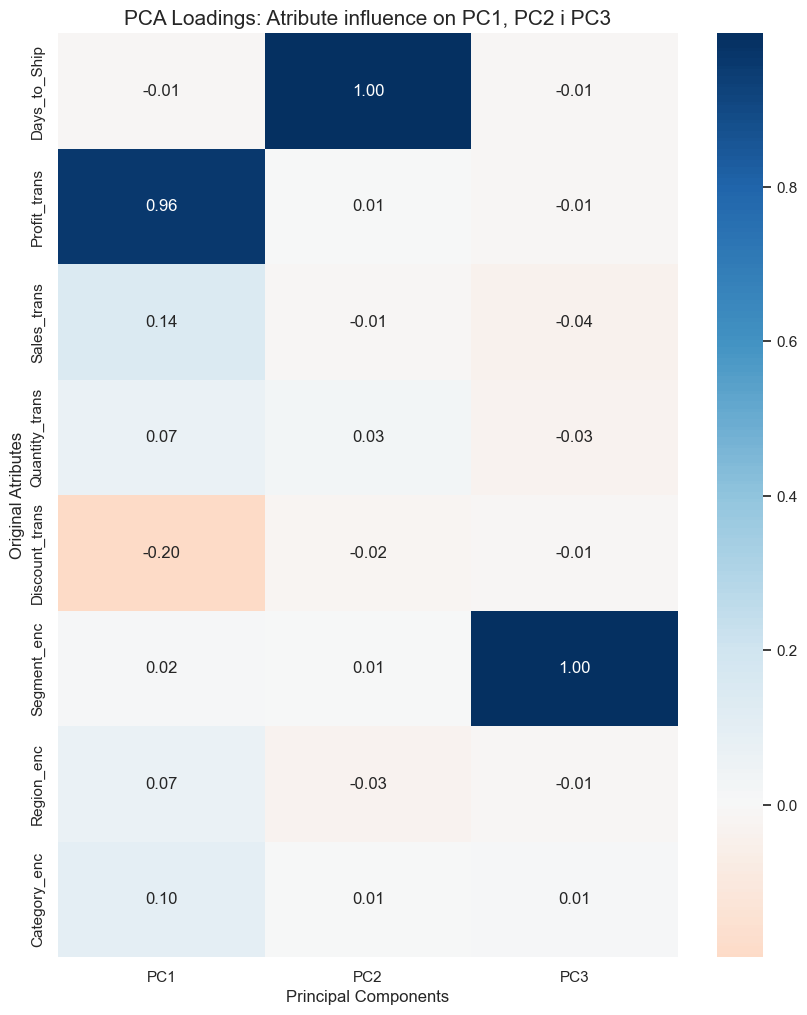

In [60]:
loadings_3d = pd.DataFrame(
    pca_3d.components_.T, 
    columns=['PC1', 'PC2', 'PC3'], 
    index=data_final_prep_scaled.columns
)

plt.figure(figsize=(10, 12))
sns.heatmap(loadings_3d, annot=True, cmap='RdBu', center=0, fmt='.2f')

plt.title('PCA Loadings: Atribute influence on PC1, PC2 i PC3', fontsize=15)
plt.ylabel('Original Atributes')
plt.xlabel('Principal Components')
plt.show()

PC3, or the z-axis, actually represents the Segment, i.e., which segments the transactions originate from (consumers), which again makes sense because my dataset is now divided into three groups along the z-axis, and the Segment is indeed composed of Consumer, Corporate, and Home Office. <br>



Again, as with delivery speed, it can be concluded here that all three transaction groups are present within each consumer type—this is significant because the purchasing policy of each can be visually observed.

In [61]:
pca_3d.explained_variance_ratio_

array([0.4281796 , 0.1446524 , 0.11002158])

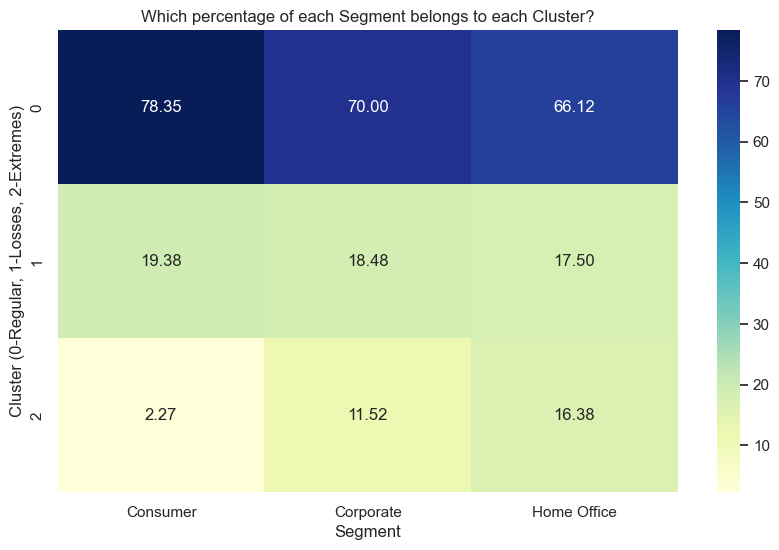

In [63]:
segment_pct = pd.crosstab(
    data['Hierarchical_Labels'], 
    data['Segment'], 
    normalize='columns'
) * 100





plt.figure(figsize=(10, 6))
sns.heatmap(segment_pct, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Which percentage of each Segment belongs to each Cluster?')
plt.ylabel('Cluster (0-Regular, 1-Losses, 2-Extremes)')
plt.show()


Based on the numbers, it can actually be seen that regular buyers (Consumer) are the least likely to opt for extreme purchases, which is logical as they have the fewest resources, but they contribute the most to losses because they hunt for large discounts. <br>



Small businesses (Home Office) have the most balanced distribution of purchases, making them our most appreciated customers. This is proof that they were previously correctly encoded with the highest value. <br>



Corporations are somewhere in between, focused on standard purchasing, using discounts when they can, but having no problem performing an extreme transaction as well

-------------

## Conclusion - Descriptive Analysis of Results

In [64]:
cols_to_drop = ['KMeans_Labels', 'HDBSCAN_Labels', 'HDBSCAN_Labels_V2', 'MeanShift_Labels']
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])


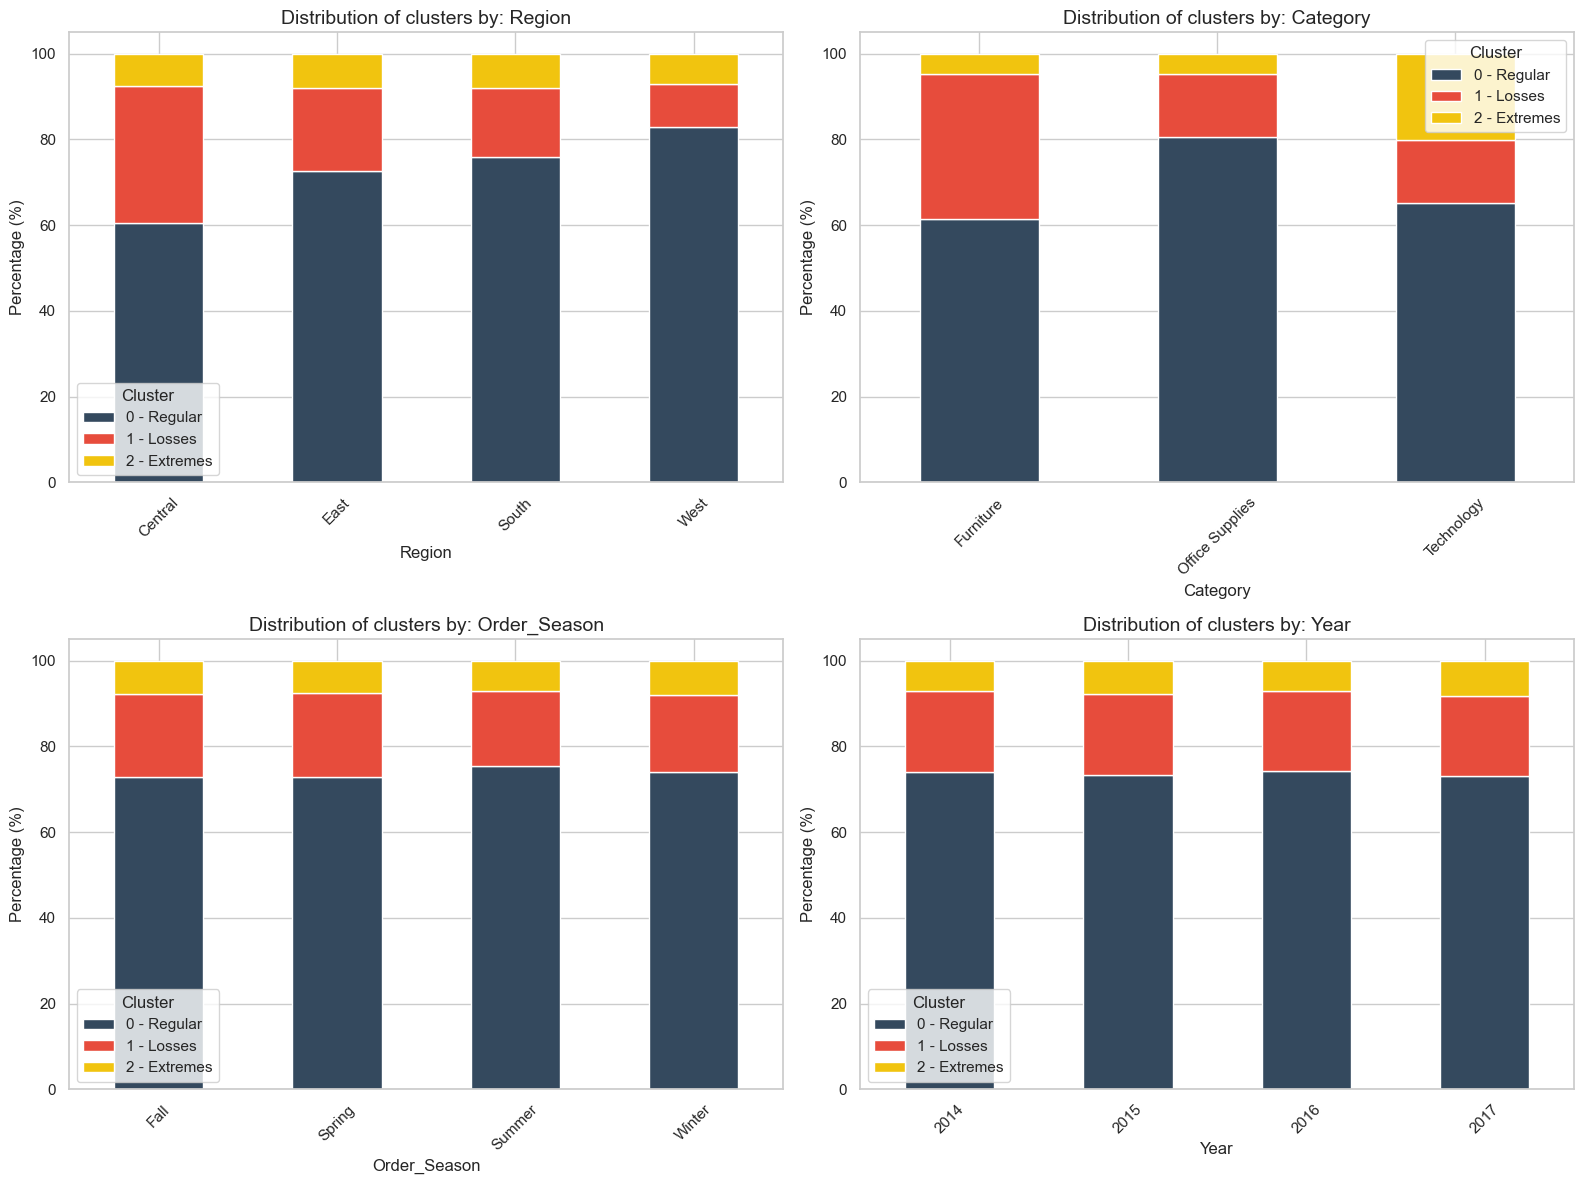

In [65]:
features_to_plot = ['Region', 'Category', 'Order_Season', 'Year']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    temp_pct = pd.crosstab(data[col], data['Hierarchical_Labels'], normalize='index') * 100
    
    
    temp_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#34495e', '#e74c3c', '#f1c40f'])
    
    axes[i].set_title(f'Distribution of clusters by: {col}', fontsize=14)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(title='Cluster', labels=['0 - Regular', '1 - Losses', '2 - Extremes'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The following conclusions were obtained: 


1. Region: Business operations in the Central region need to be improved.

2. Category: Business operations for the Furniture category need to be improved.

3. Order Season: There are no significant indicators suggesting a need for change.

4. Year: There are no significant indicators for change, though the goal should certainly be to strive for a reduction in losses in the coming year.

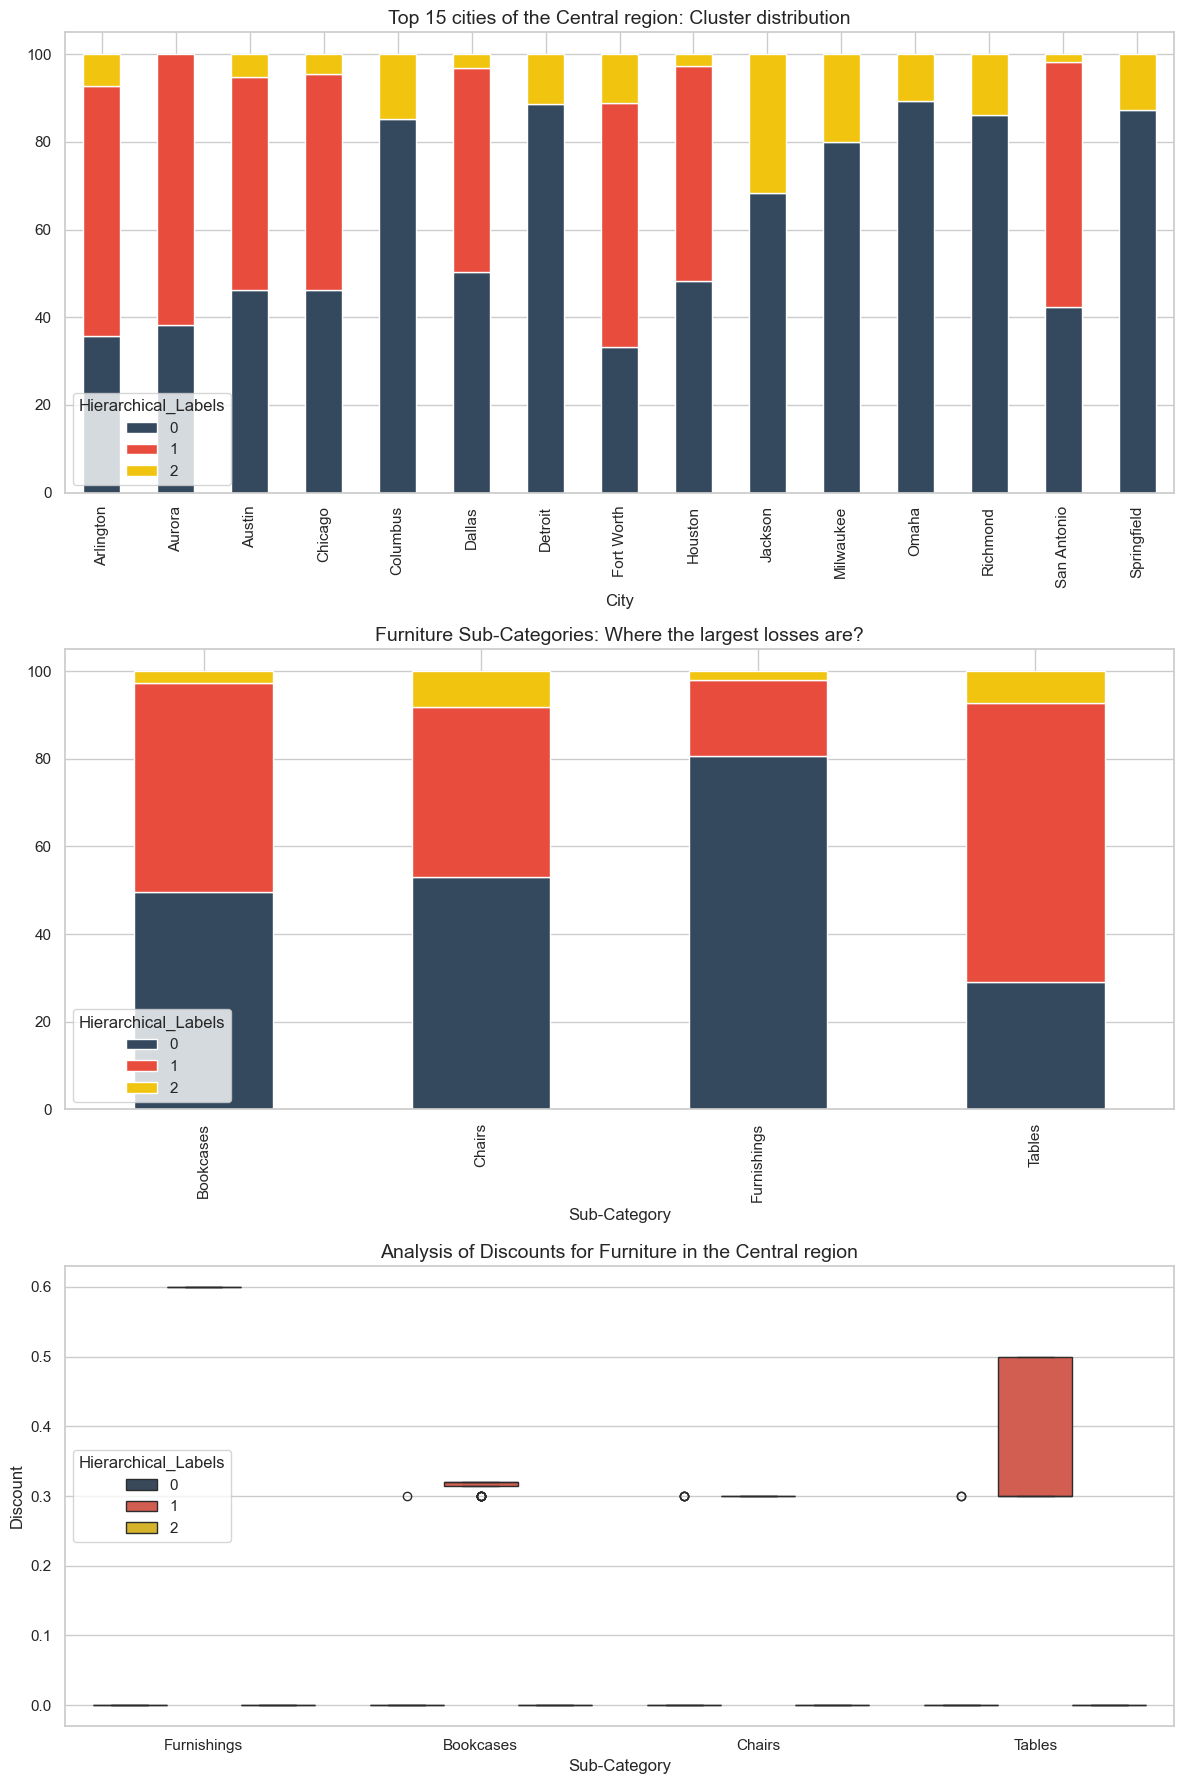

In [66]:
central_data = data[data['Region'] == 'Central']
furniture_data = data[data['Category'] == 'Furniture']
central_furniture = data[(data['Region'] == 'Central') & (data['Category'] == 'Furniture')]

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

top_cities = central_data['City'].value_counts().nlargest(15).index
central_cities_pct = pd.crosstab(central_data[central_data['City'].isin(top_cities)]['City'], 
                                 central_data['Hierarchical_Labels'], normalize='index') * 100
central_cities_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#34495e', '#e74c3c', '#f1c40f'])
axes[0].set_title('Top 15 cities of the Central region: Cluster distribution', fontsize=14)

furniture_sub_pct = pd.crosstab(furniture_data['Sub-Category'], 
                                furniture_data['Hierarchical_Labels'], normalize='index') * 100
furniture_sub_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#34495e', '#e74c3c', '#f1c40f'])
axes[1].set_title('Furniture Sub-Categories: Where the largest losses are?', fontsize=14)

sns.boxplot(x='Sub-Category', y='Discount', hue='Hierarchical_Labels', data=central_furniture, ax=axes[2], palette=['#34495e', '#e74c3c', '#f1c40f'])
axes[2].set_title('Analysis of Discounts for Furniture in the Central region', fontsize=14)

plt.tight_layout()
plt.show()

We have now identified the cities in the Central region where business performance needs improvement, as well as the specific furniture items that require operational adjustments. <br>



Additionally, we can see that the discount percentages for furniture in the Central region are, on average, quite high (over 30%).